In [1]:
# Loading important modules

import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
from pathlib import Path

# Library in splitting data
from sklearn.model_selection import train_test_split

# libaries to help with visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removing limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Setting limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Different Libraries to ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# For tunning model different models
from sklearn.model_selection import GridSearchCV

In [2]:
print("Initializing Notebook")
file_path = "https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/EasyVisa%20(1).csv"
df = pd.read_csv(file_path)
print("Shape:", df.shape)
df.head()

Initializing Notebook
Shape: (25480, 12)


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [3]:
cat_col = df.select_dtypes("object").columns.drop('case_id')
num_col = df.select_dtypes(["float64", "Int64"]).columns

In [4]:
def neg_val(df):
    # if (df[df["no_of_employees"] < 0]).all():
    df["no_of_employees"] = df["no_of_employees"].abs()
    return df

In [5]:
df = neg_val(df)
df[df["no_of_employees"] < 0]


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status


In [6]:
df.head(246)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
241,EZYV242,Oceania,Doctorate,Y,N,2871,2009,South,56606.5400,Month,Y,Certified
242,EZYV243,Africa,Bachelor's,N,Y,2509,2003,West,51886.0400,Year,Y,Denied
243,EZYV244,North America,Master's,N,N,1720,1995,Northeast,62112.2200,Week,Y,Denied
244,EZYV245,Europe,Doctorate,Y,N,1760,1997,South,63108.0300,Year,Y,Certified


In [7]:
def summary_info(df):
    print('Shape:', df.shape)
    print('\nMissing values:')
    print(df.isnull().sum())
    print('\nData types:')
    print(df.dtypes)

def missing_report(df):
    miss = df.isnull().sum()
    miss = miss[miss>0].sort_values(ascending=False)
    return miss

def numerical_stats(df, num_col):
    # num_col = df.select_dtypes(["float64", "Int64"]).columns
    for num in num_col:
        print("*" * 50)
        print(df[num].nunique())

def categorical_stats(df, cat_col):
    # cat_col = df.select_dtypes("object").columns.drop('case_id')
    for col in cat_col:
        print("*" * 50)
        print(df[col].value_counts())

def plot_numeric_hist(df, num_col, bins=30):
    for col in num_col:
        fig, ax = plt.subplots(figsize=(6,4))
        ax.hist(df[col].dropna(), bins=bins)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()

def plot_categorical_bar(df, cat_col):
    for col in cat_col:
        counts = df[col].value_counts(dropna=False)
        fig, ax = plt.subplots(figsize=(6,4))
        counts.plot(kind='bar', ax=ax)
        ax.set_title(f'Counts of {col}')
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()

In [8]:
summary_info(df)

Shape: (25480, 12)

Missing values:
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

Data types:
case_id                   object
continent                 object
education_of_employee     object
has_job_experience        object
requires_job_training     object
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
prevailing_wage          float64
unit_of_wage              object
full_time_position        object
case_status               object
dtype: object


In [9]:
missing_report(df)

Series([], dtype: int64)

In [10]:
#num_col = df.select_dtypes(["float64", "Int64"]).columns
numerical_stats(df, num_col)

**************************************************
7105
**************************************************
199
**************************************************
25454


In [11]:
# cat_col = df.select_dtypes("object").columns
# cat_col = df.select_dtypes("object").columns.drop('case_id')
categorical_stats(df, cat_col)

**************************************************
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
**************************************************
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
**************************************************
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
**************************************************
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
**************************************************
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
**************************************************
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
***************

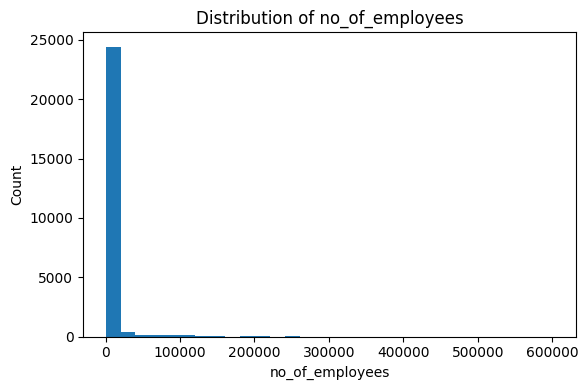

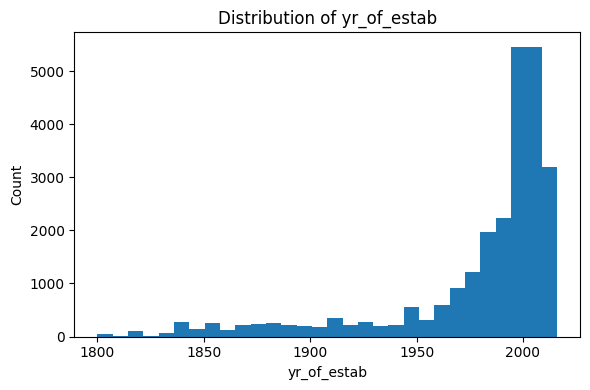

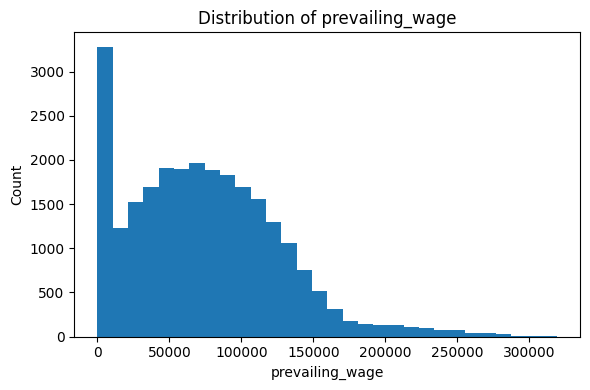

In [12]:
# num_col=df.select_dtypes(["float64", "Int64"]).columns
plot_numeric_hist(df, num_col)

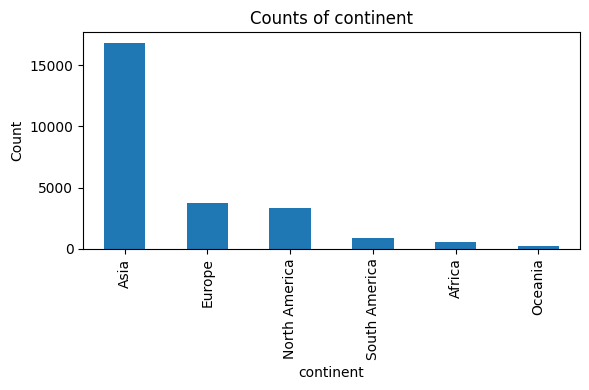

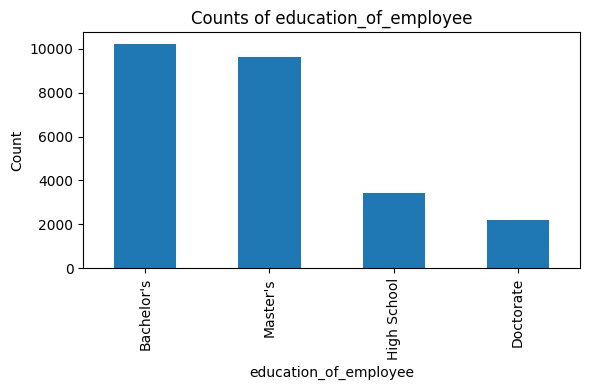

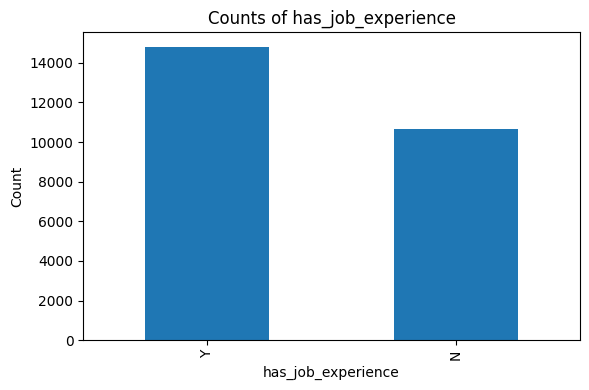

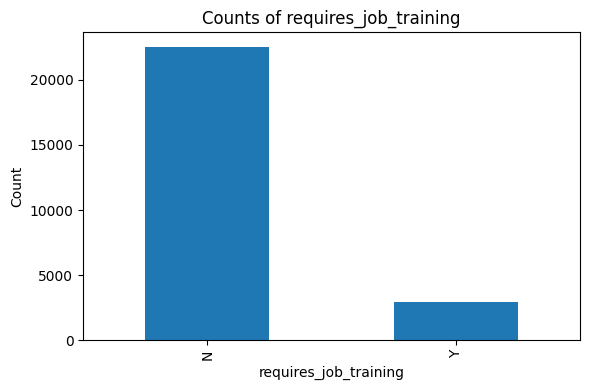

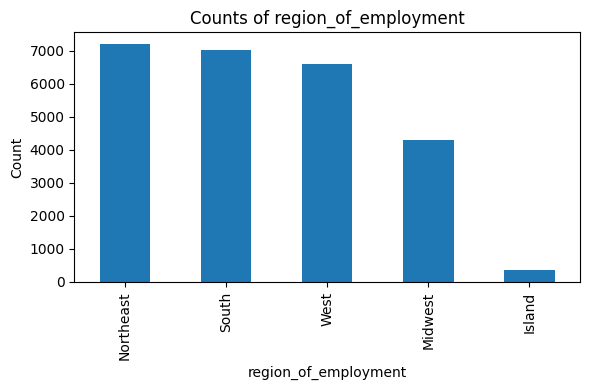

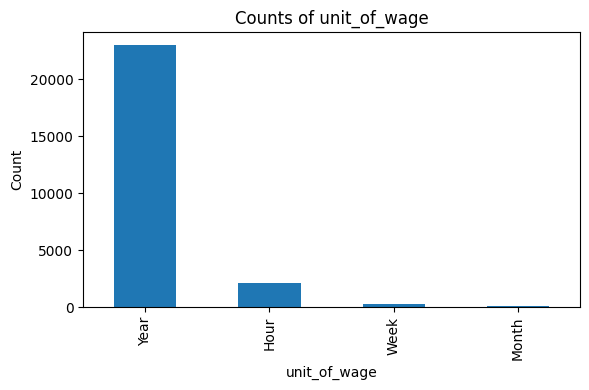

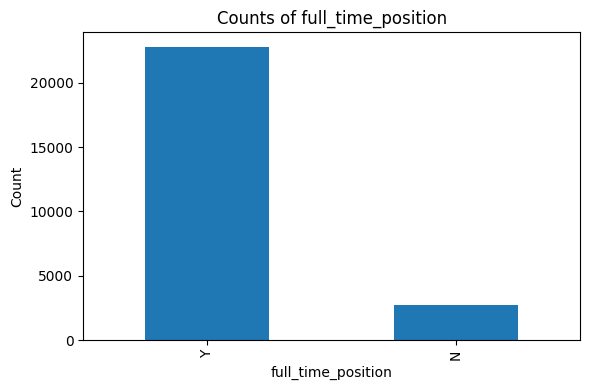

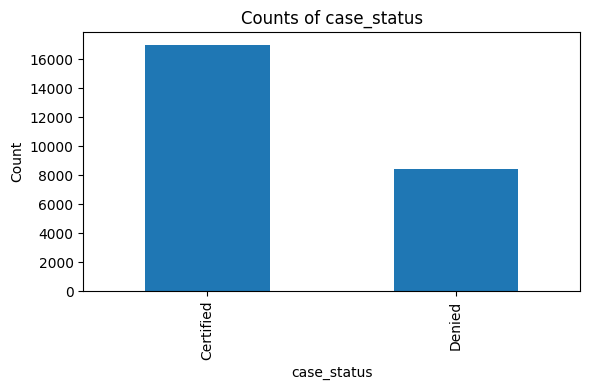

In [13]:
# cat_col = df.select_dtypes("object").columns.drop('case_id')
plot_categorical_bar(df, cat_col)

In [14]:
def histogram_boxplot(df, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df[feature].mean(), color="green", linestyle="--"
    )  # Adding mean to the histogram
    ax_hist2.axvline(
        df[feature].median(), color="black", linestyle="-"
    )  # Adding median to the histogram

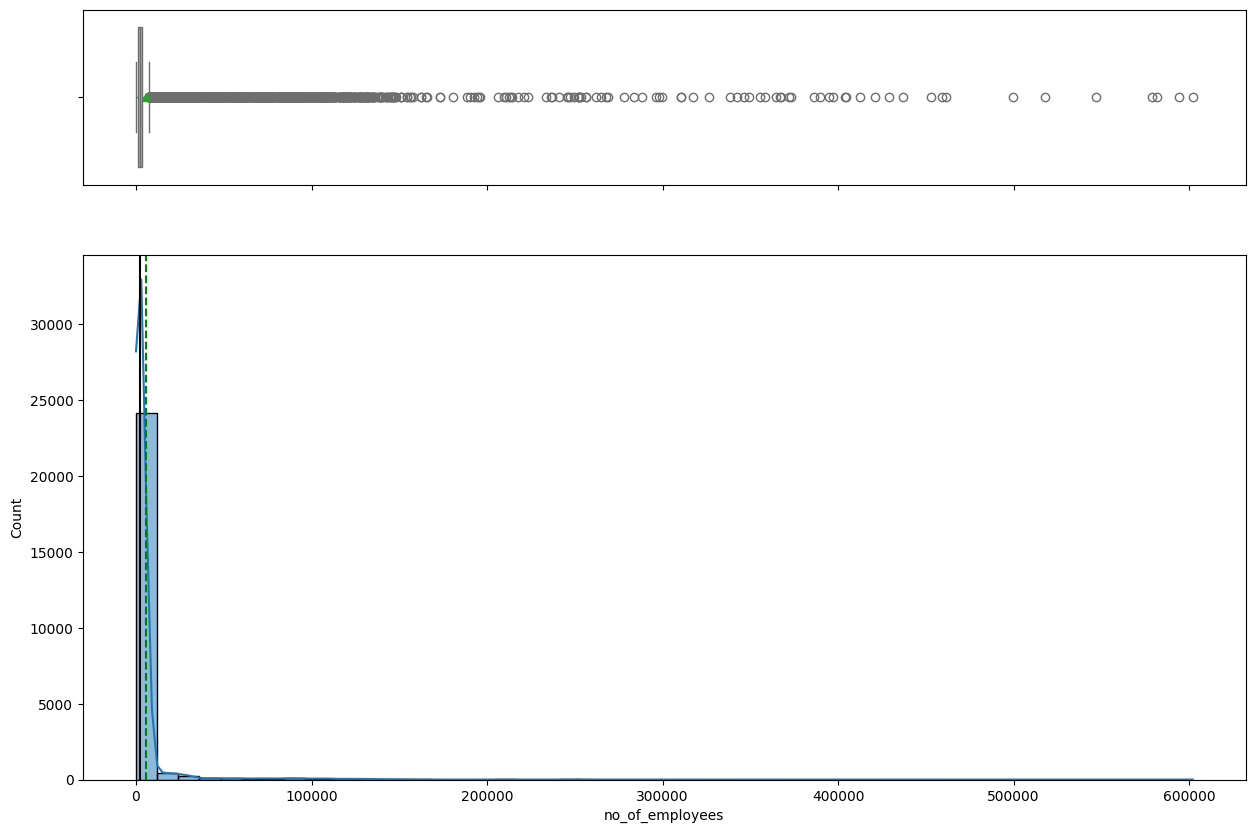

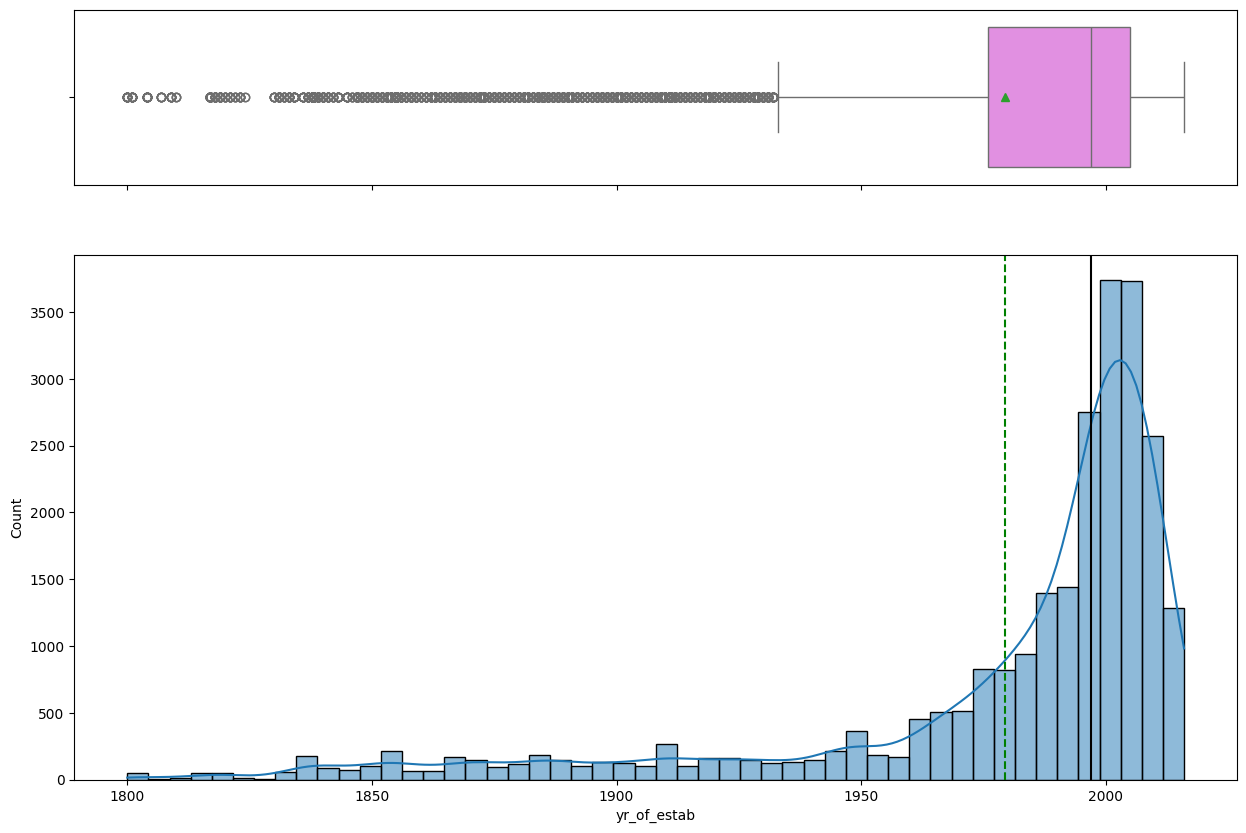

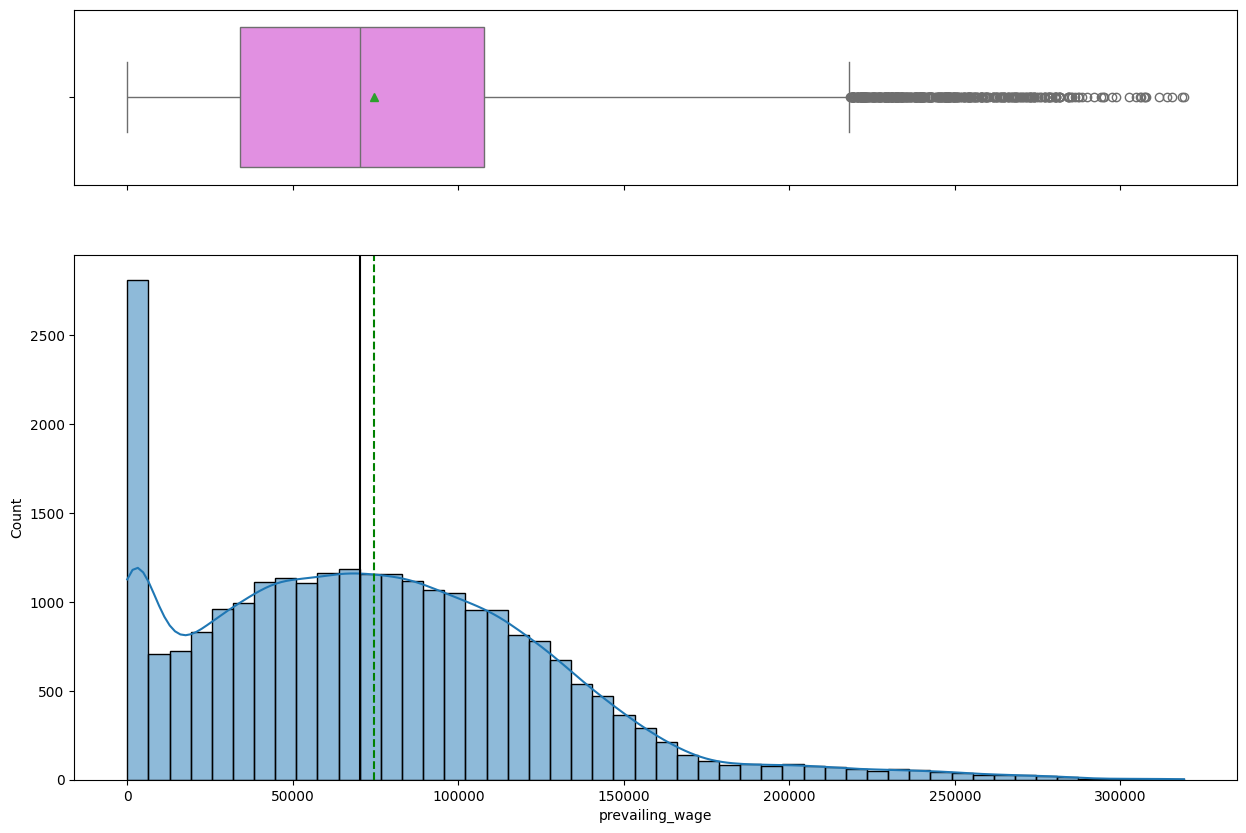

In [15]:
# cat_col = df.select_dtypes("object").columns.drop('case_id')
for num in num_col:
    histogram_boxplot(df, num, kde=True, bins=50)

In [16]:
# creating labeled barplot
def labeled_barplot(df, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(df[feature])
    count = df[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=df,
        x=feature,
        palette="Paired",
        order=df[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

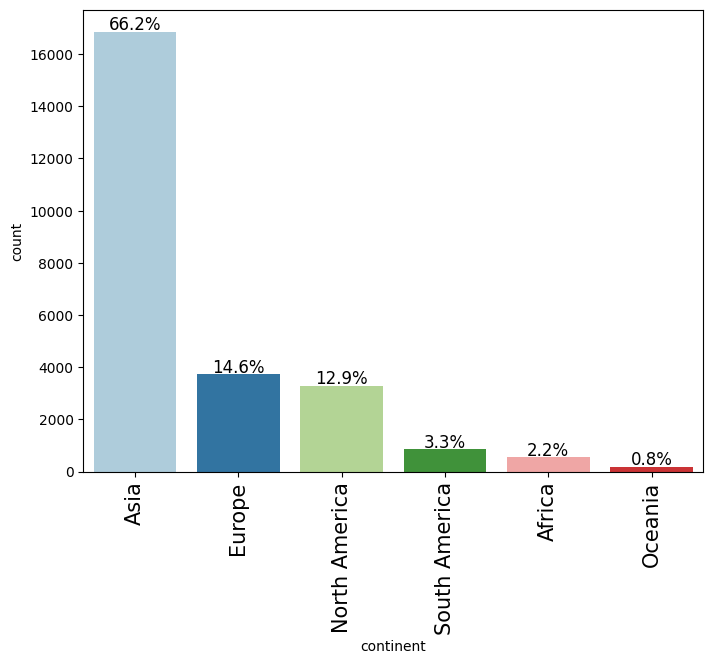

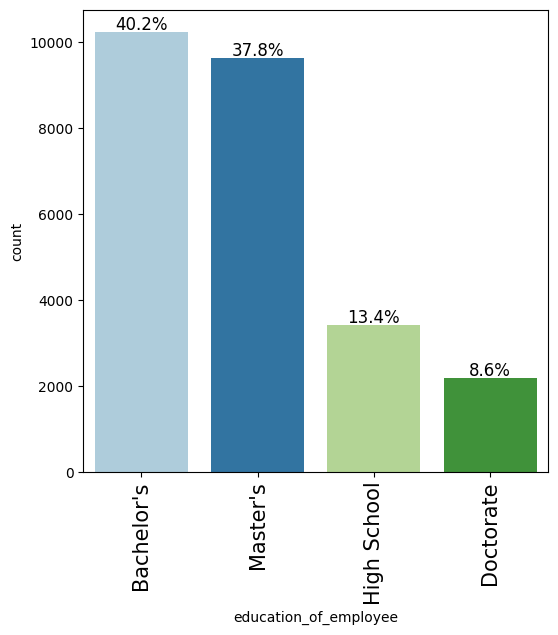

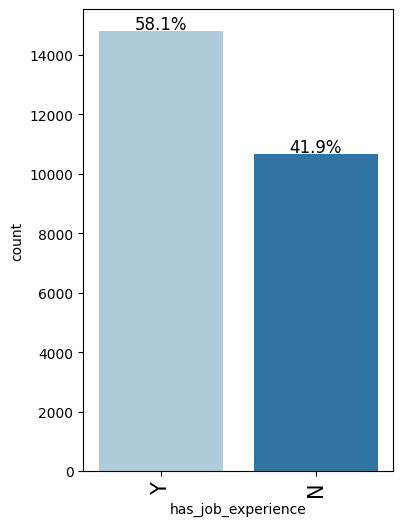

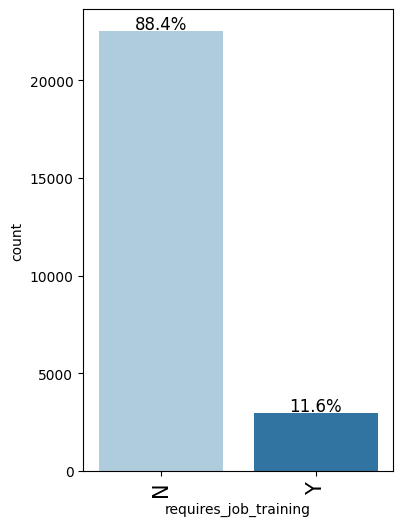

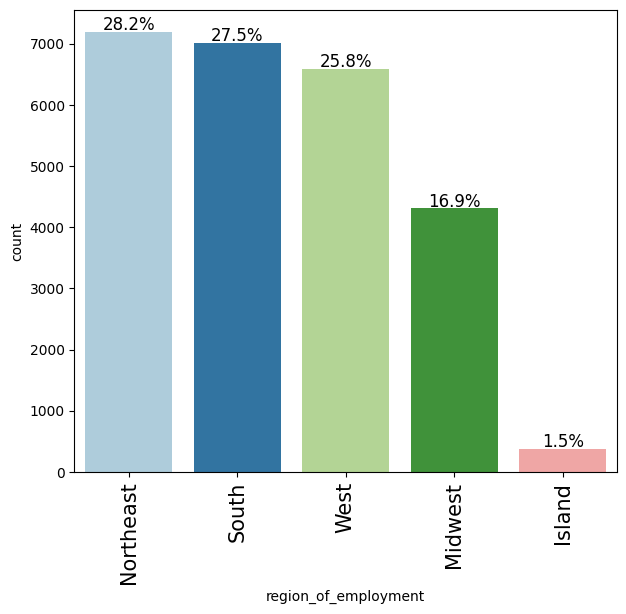

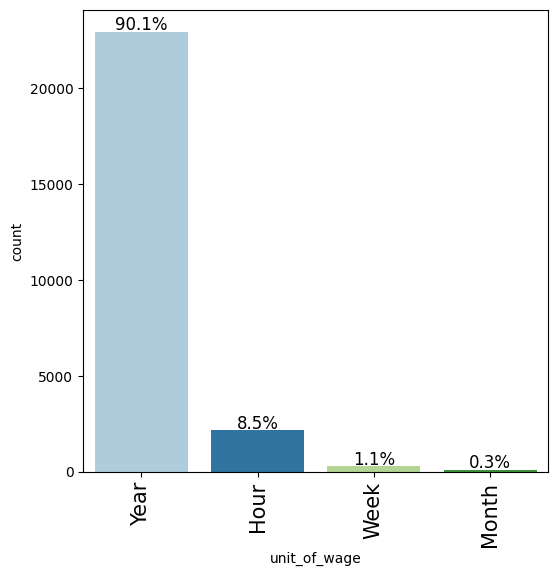

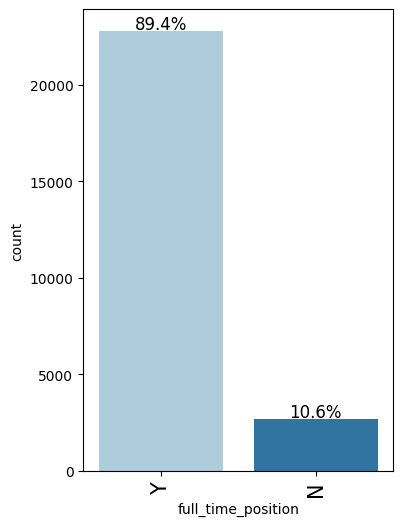

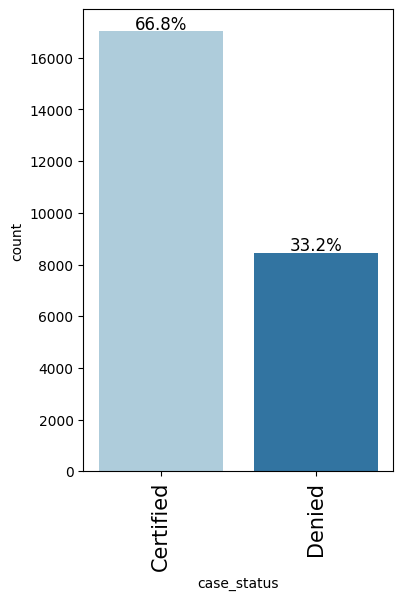

In [17]:
for cat in cat_col:
    labeled_barplot(df, cat, perc=True)

In [18]:

def correlation(df, num_col):
    plt.figure(figsize=(10, 5))
    sns.heatmap(
    df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Accent"
    )
    plt.show()

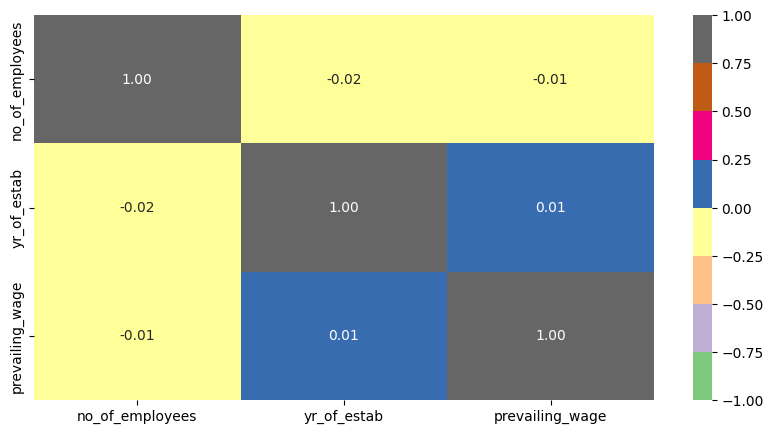

In [19]:
correlation(df, num_col)

In [20]:
def distribution_plot_wrt_target(df, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = df[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=df[df[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=df[df[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=df, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=df,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

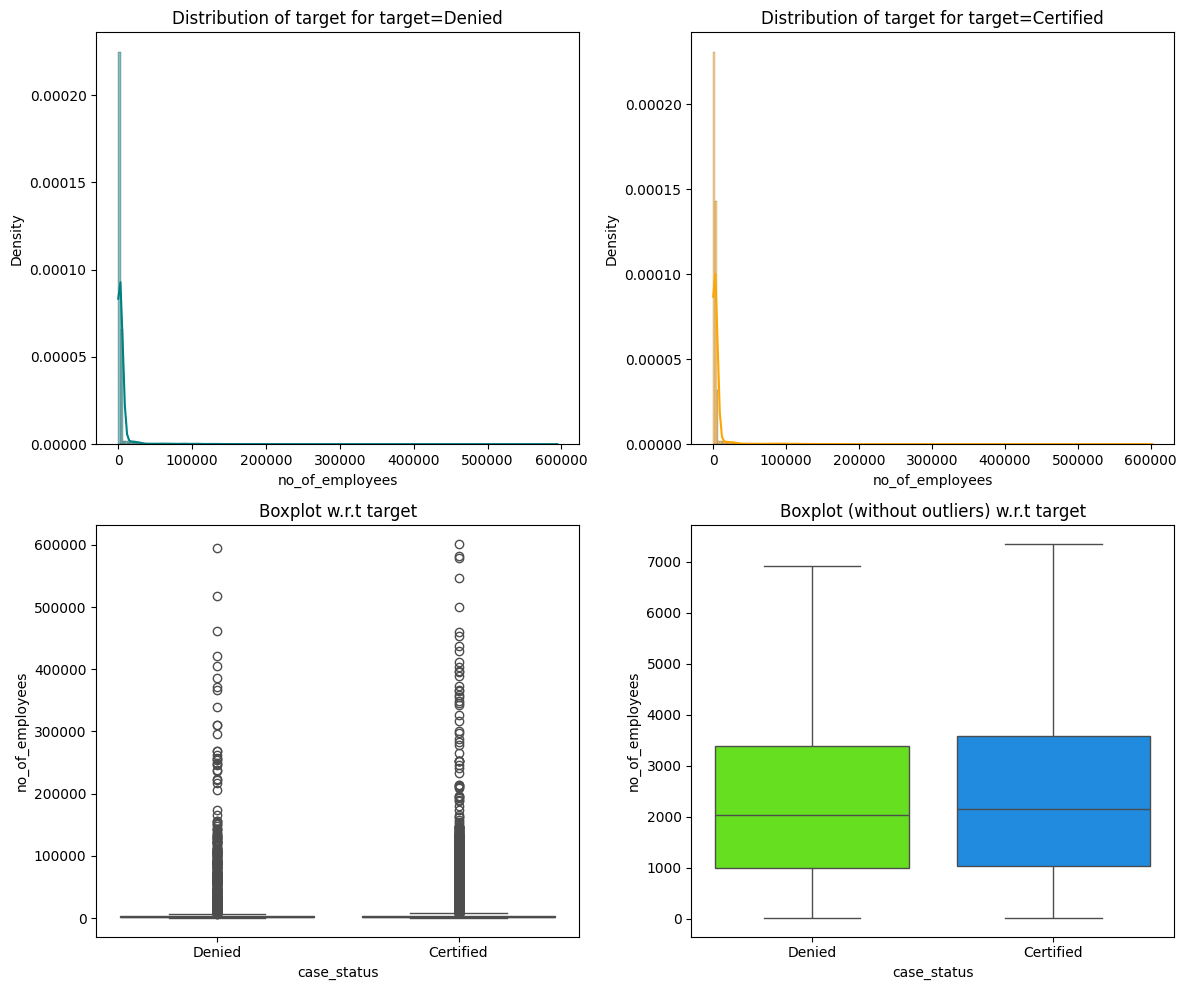

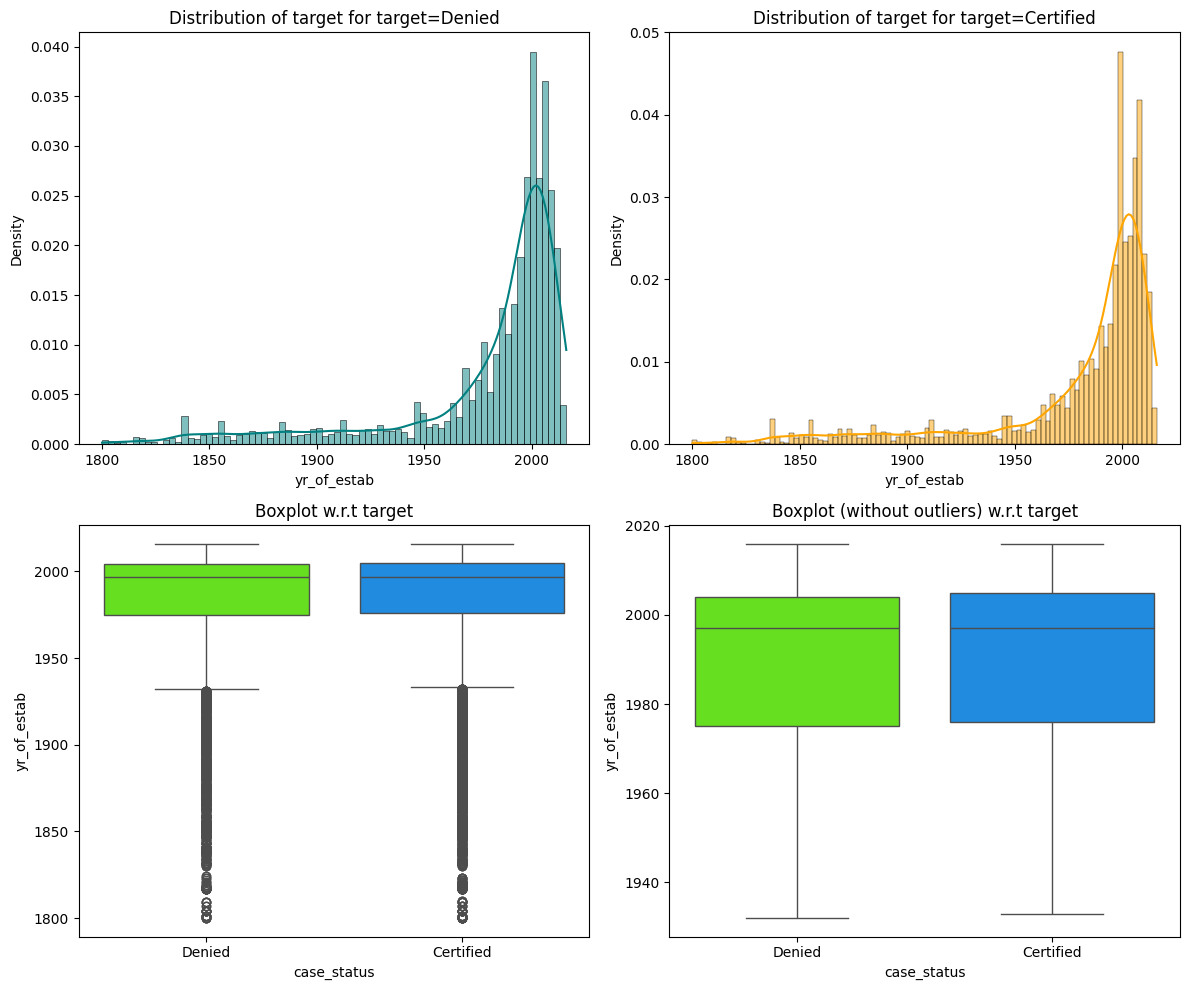

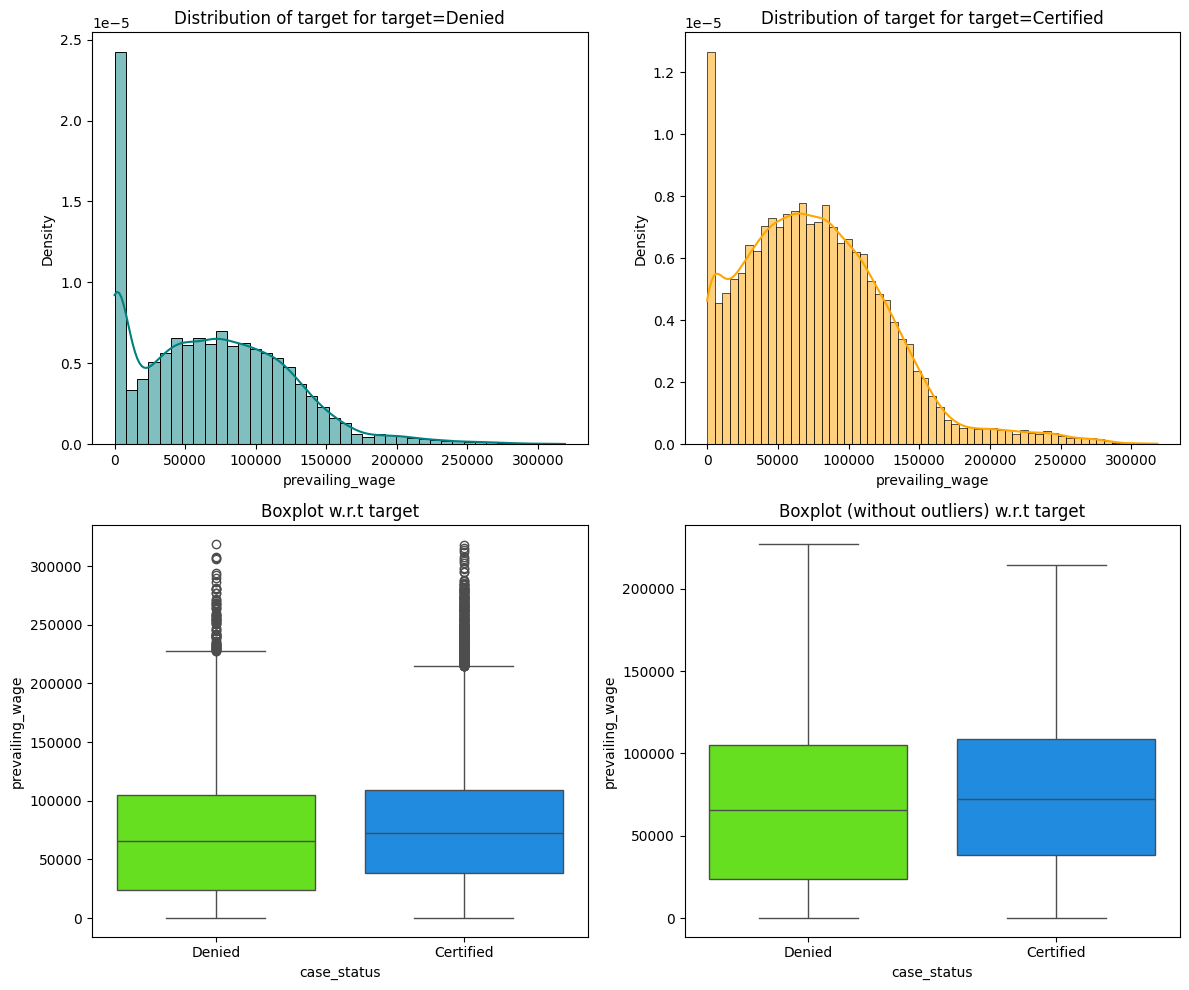

In [21]:
for num in num_col:
    distribution_plot_wrt_target(df, num, 'case_status')

In [22]:
def stacked_barplot(df, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = df[predictor].nunique()
    sorter = df[target].value_counts().index[-1]
    tab1 = pd.crosstab(df[predictor], df[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(df[predictor], df[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


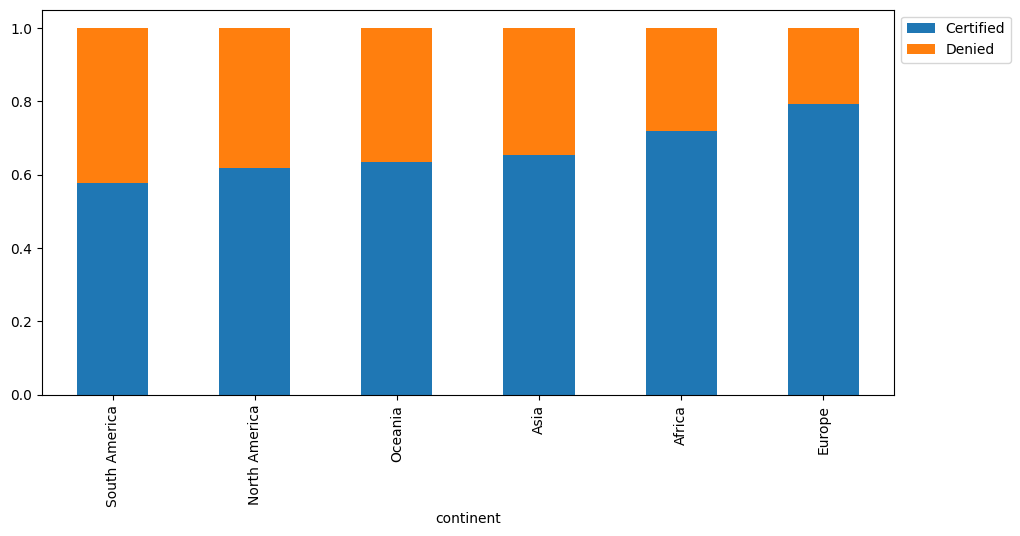

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


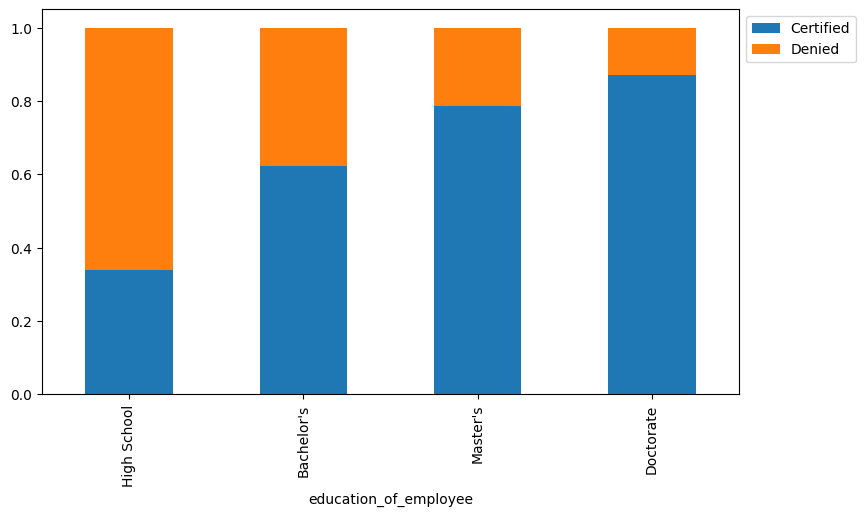

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


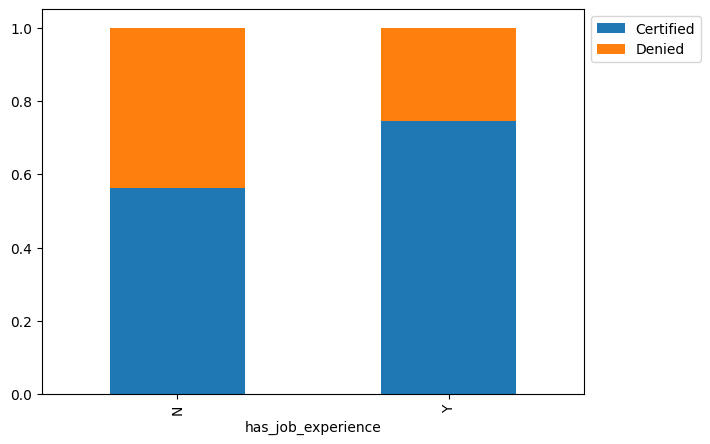

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


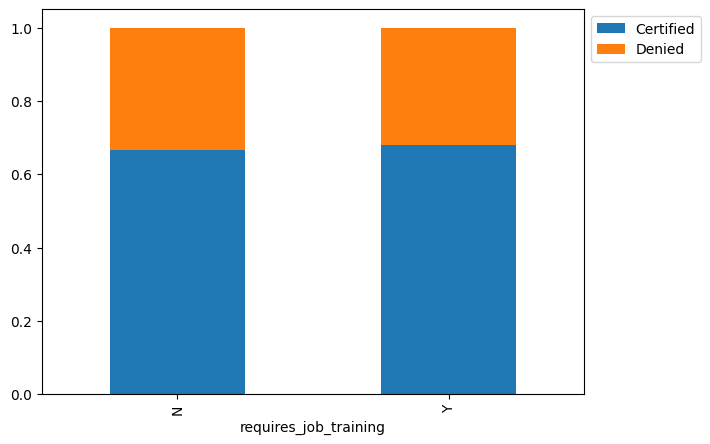

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


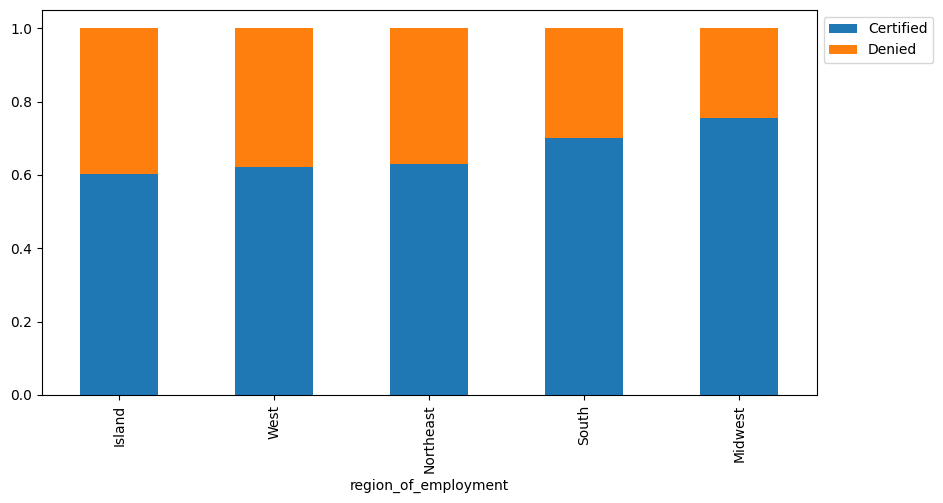

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


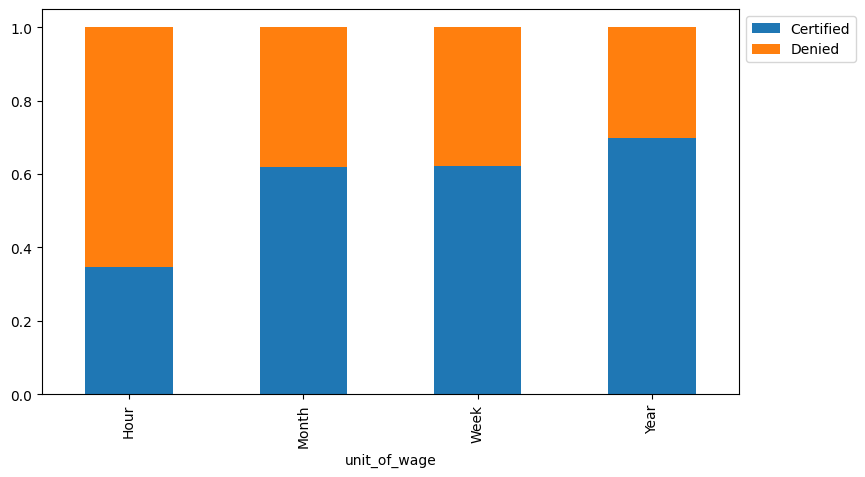

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


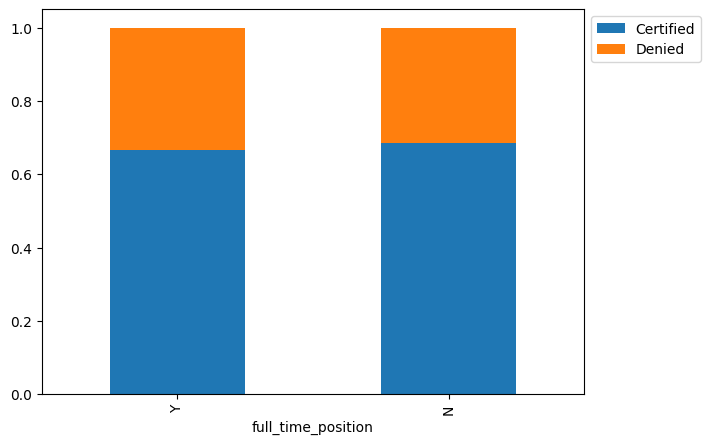

case_status  Certified  Denied    All
case_status                          
Denied               0    8462   8462
All              17018    8462  25480
Certified        17018       0  17018
------------------------------------------------------------------------------------------------------------------------


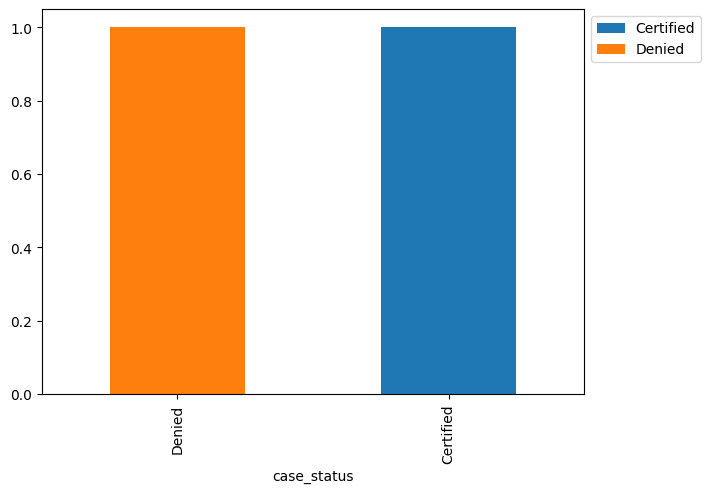

In [23]:
for cat in cat_col:
    stacked_barplot(df, cat, 'case_status')

In [24]:
cat_col

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [25]:
# num_cat = df.columns.to_list()
# num_cat.remove('case_id')

# df.columns

In [26]:
def com_feat(df, num_col, cat_col):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=cat_col, y=num_col)
    plt.show()

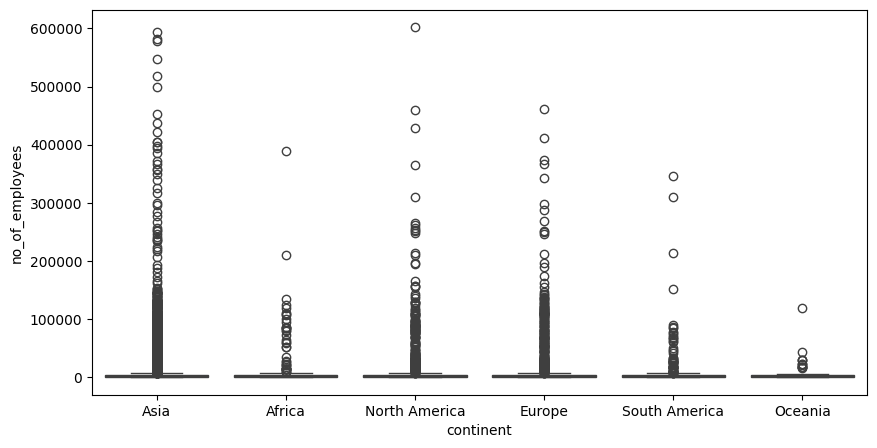

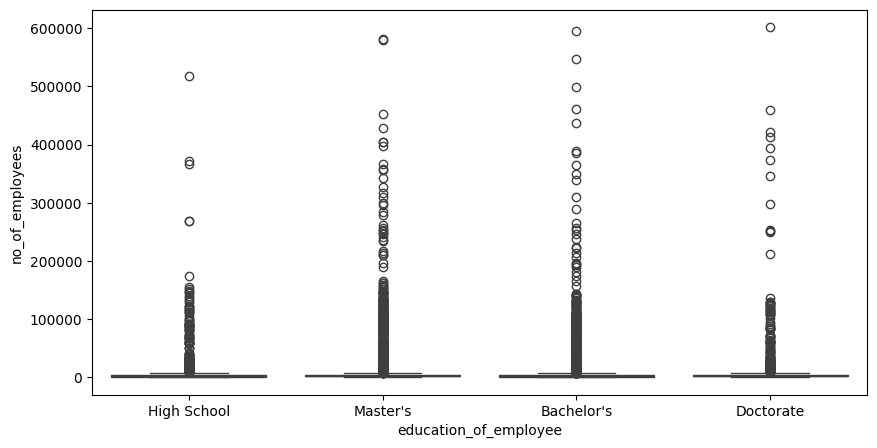

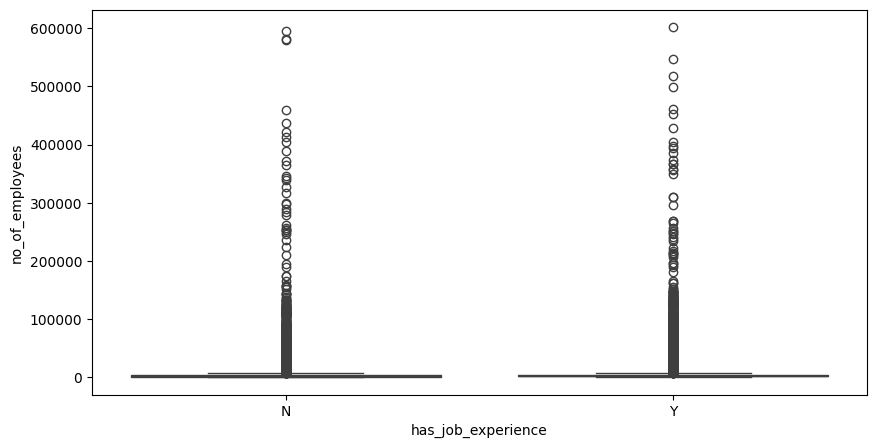

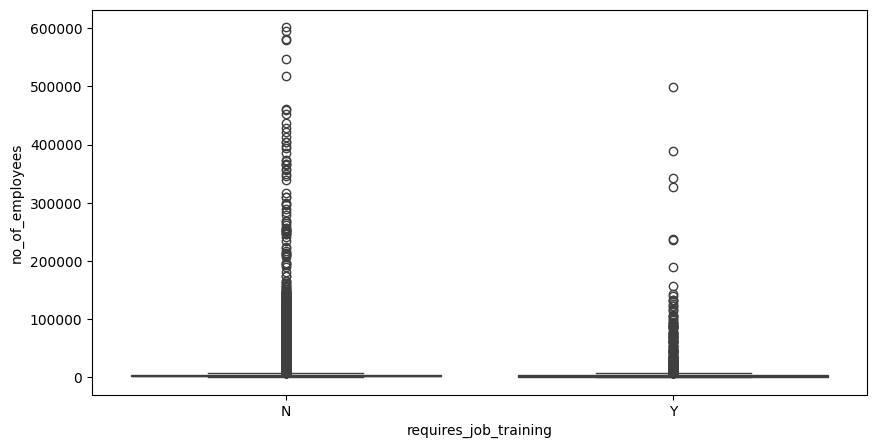

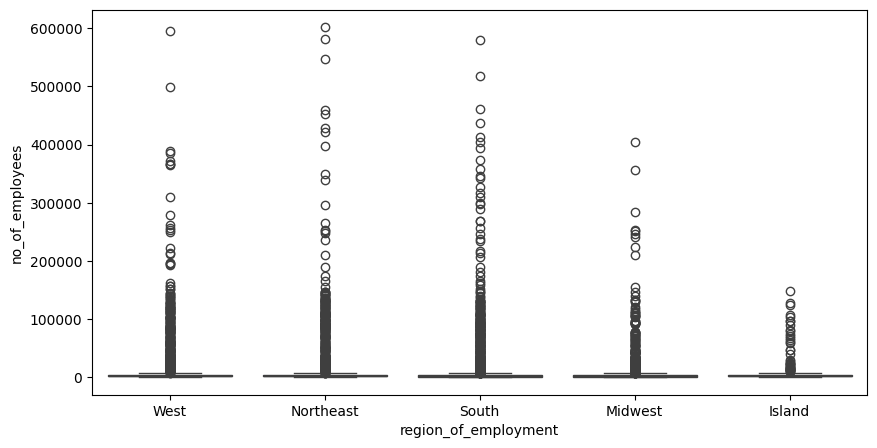

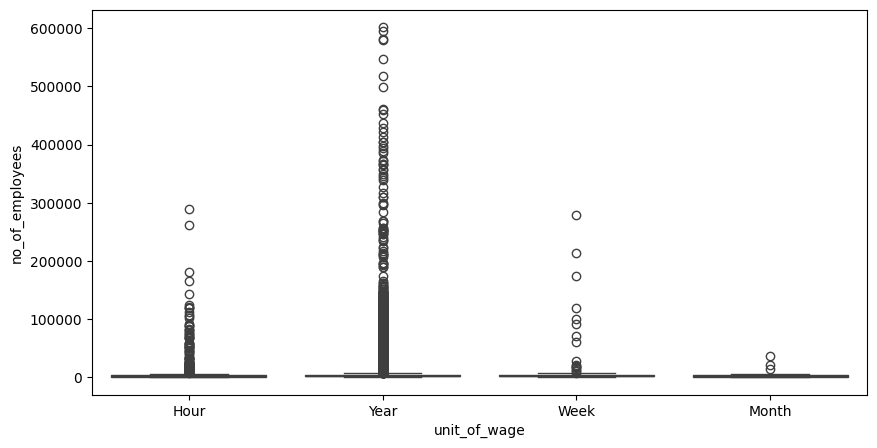

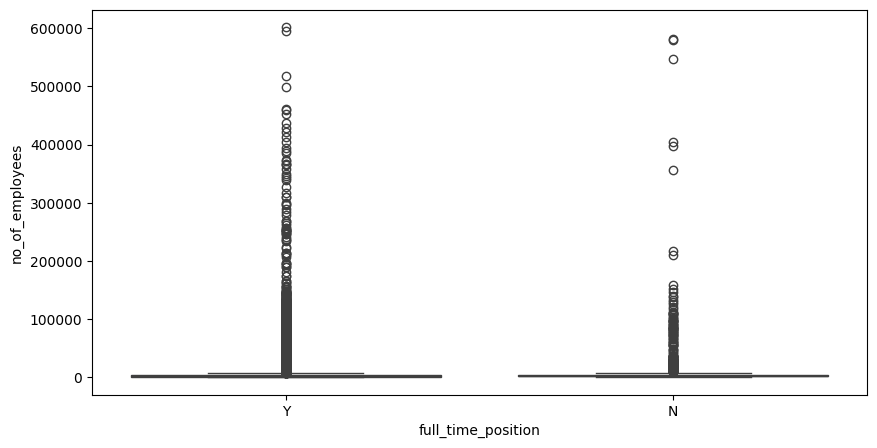

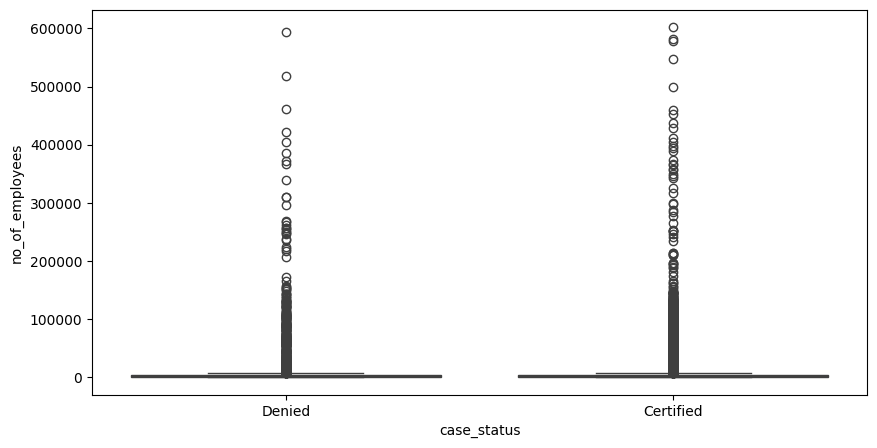

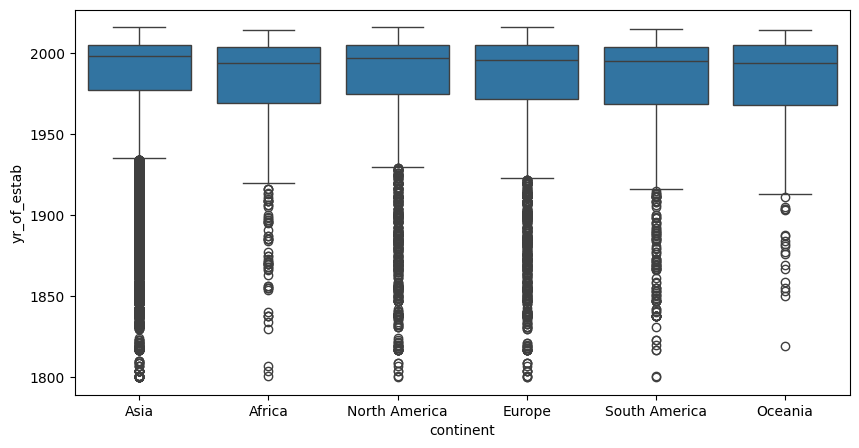

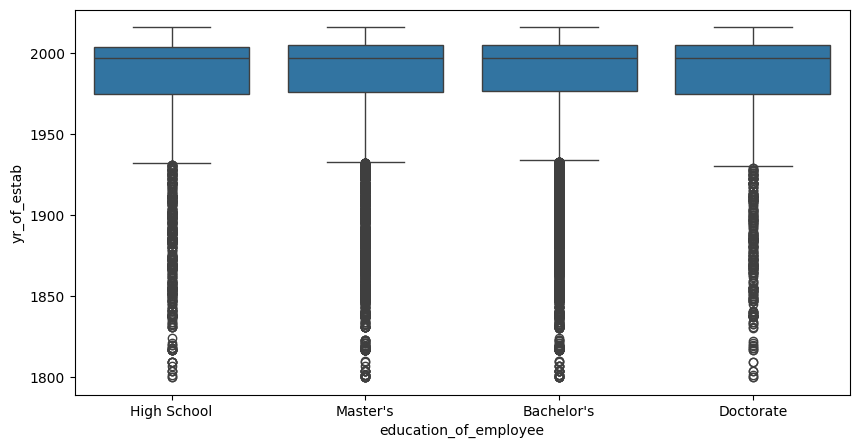

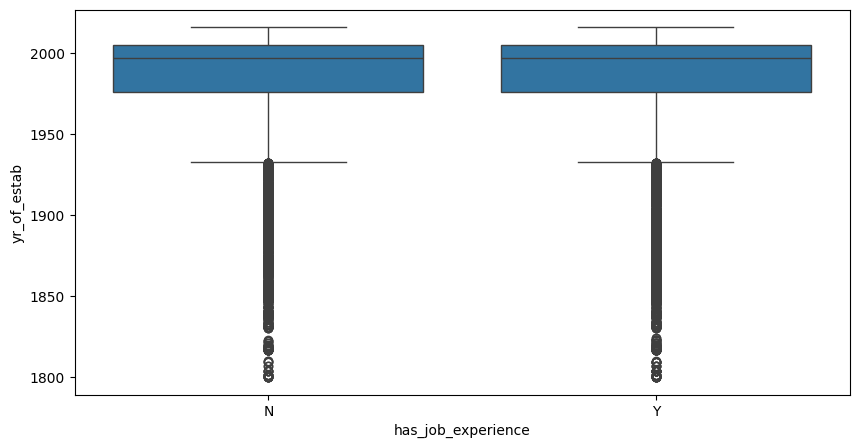

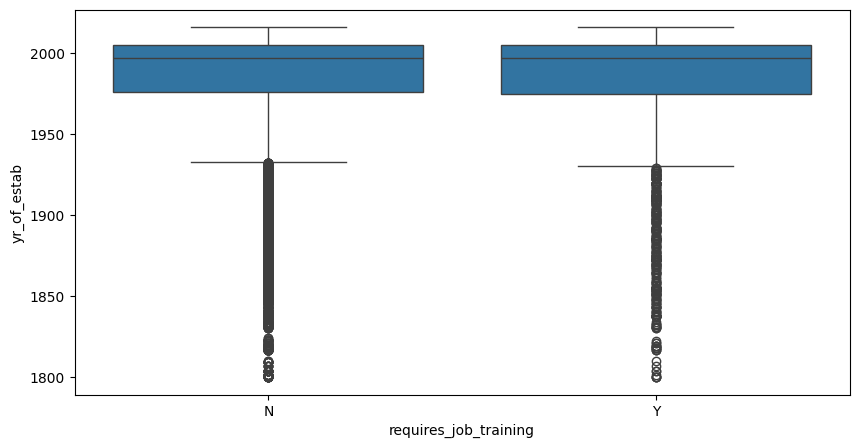

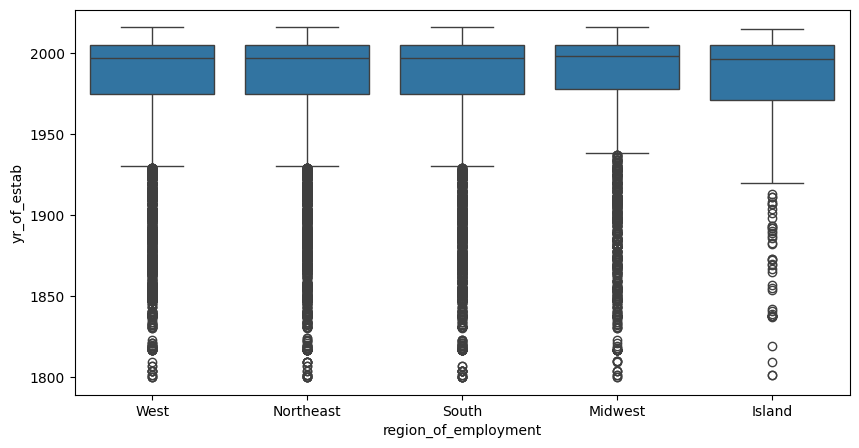

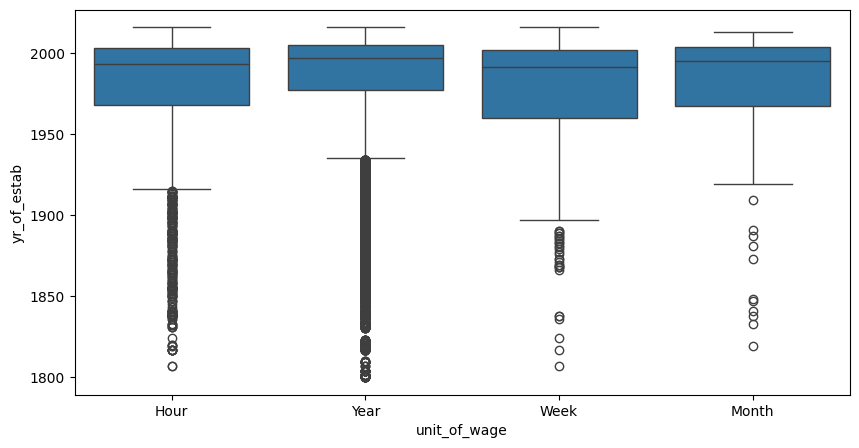

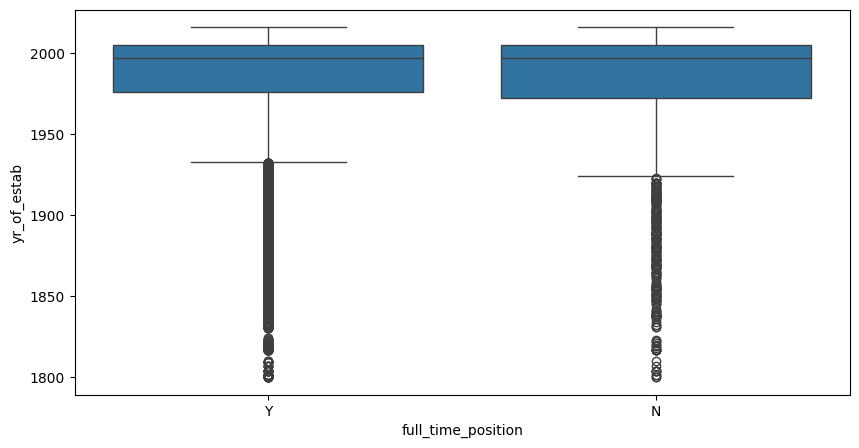

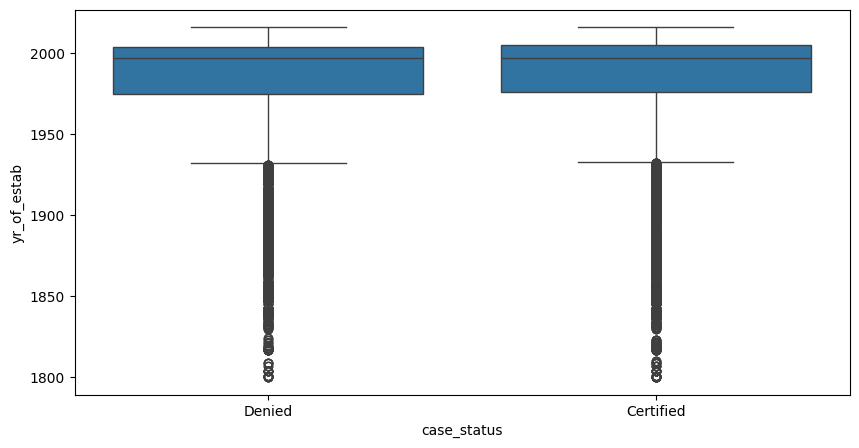

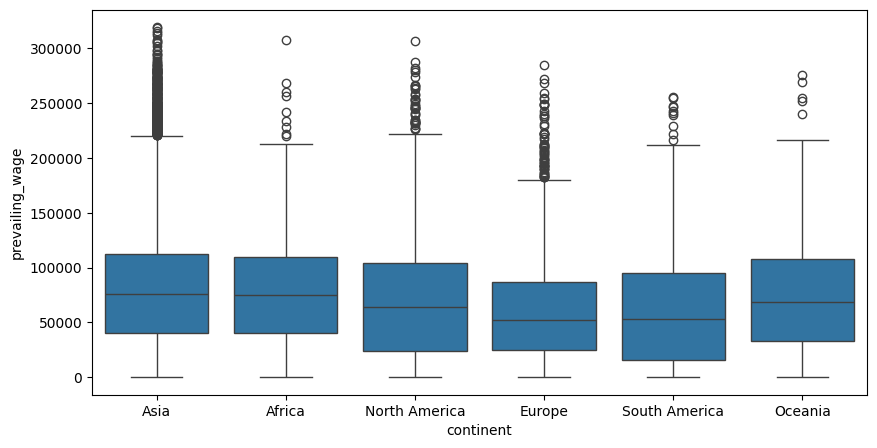

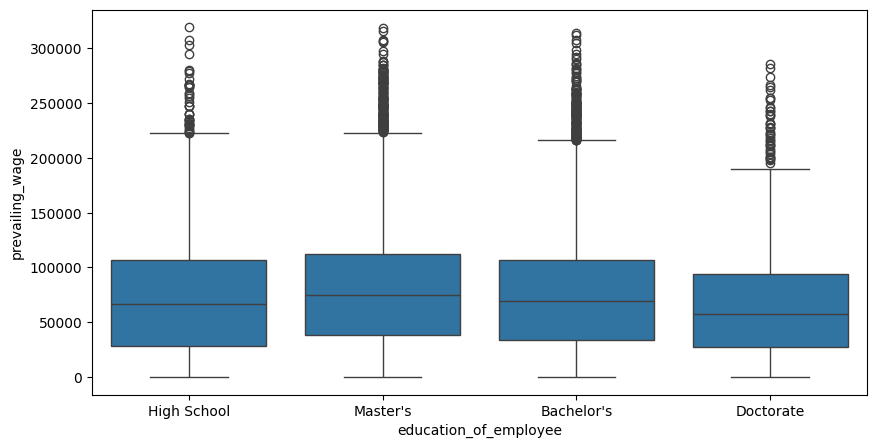

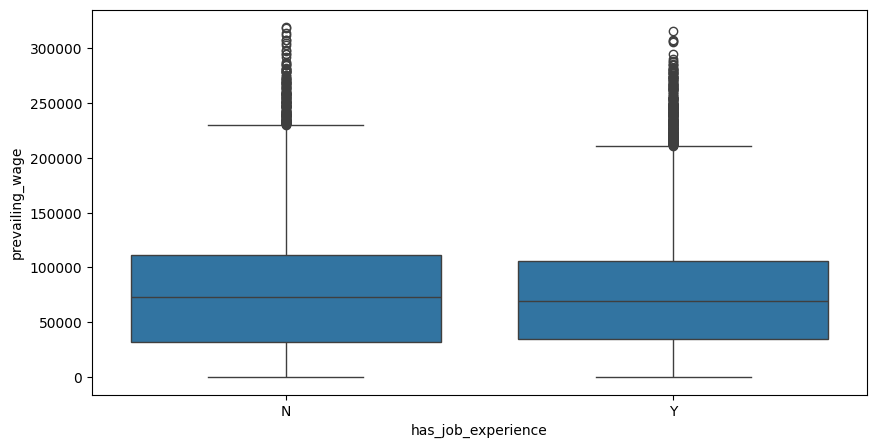

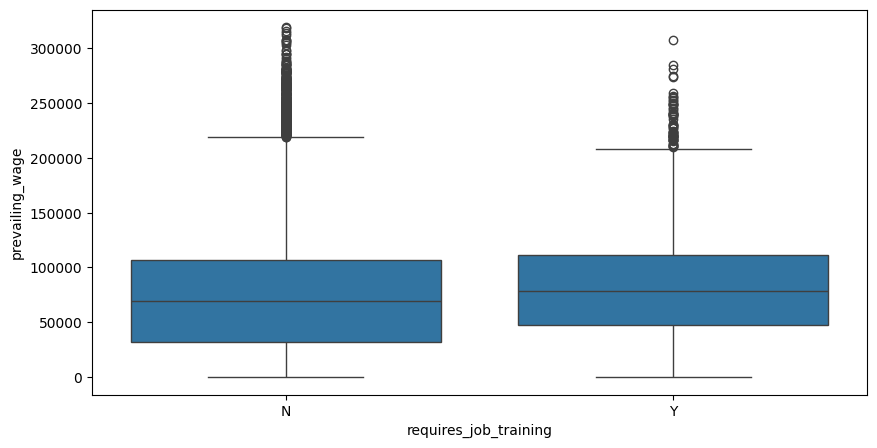

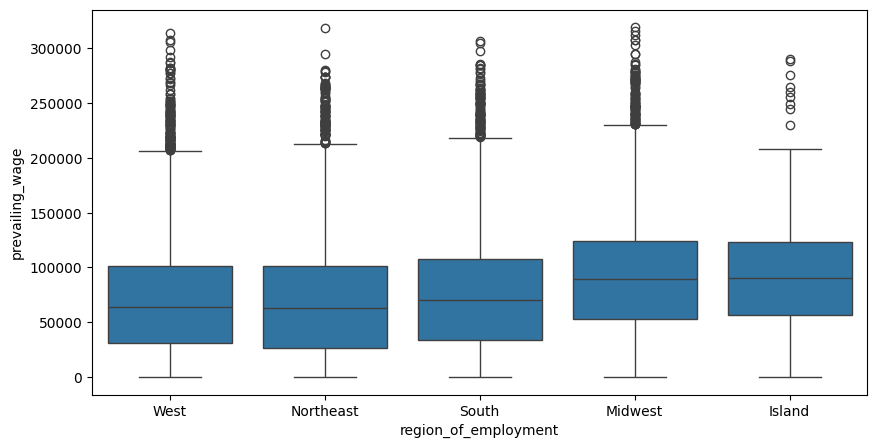

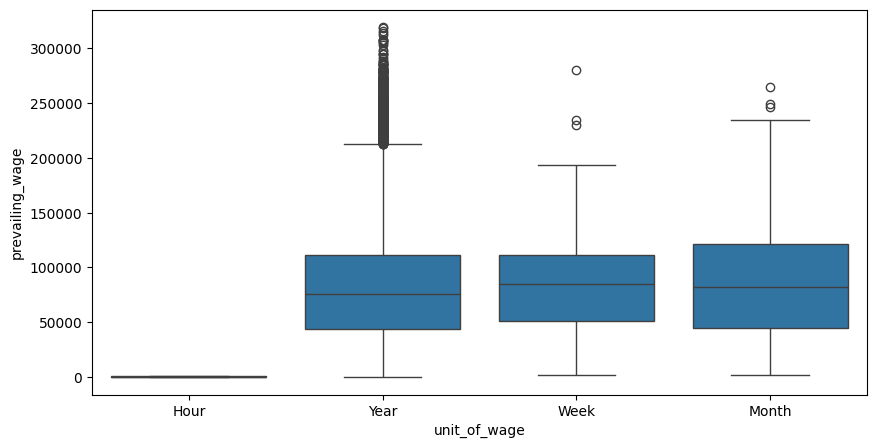

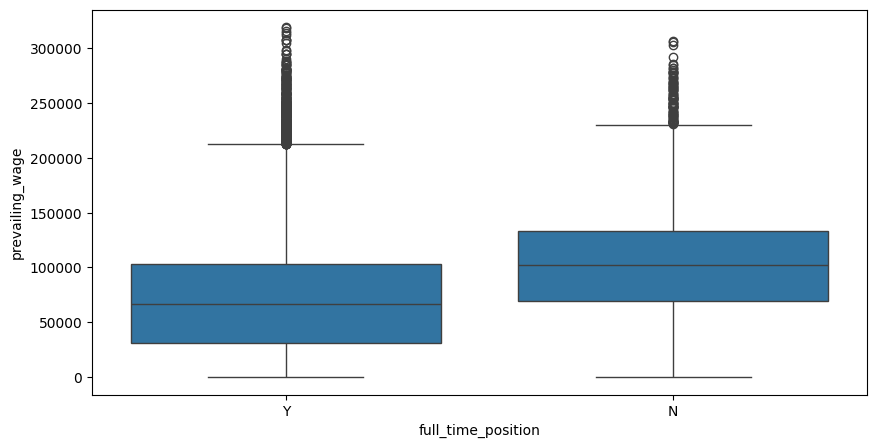

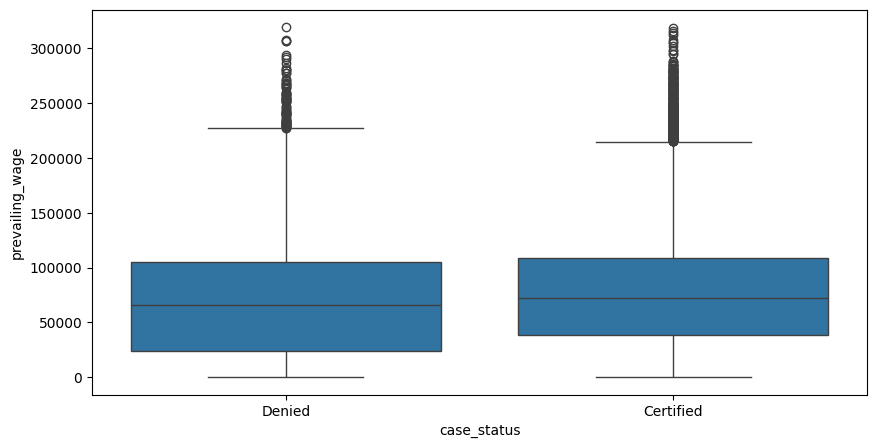

In [27]:
for num in num_col:
    for cat in cat_col:
        com_feat(df, num, cat)

### Data Preprocessing

In [28]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [29]:
def box_num(df, num_col):
    num_col = df.select_dtypes(include=np.number).columns.tolist()


    # Plot the boxplots for all numeric columns (except Risk)
    plt.figure(figsize=(8, 6))

    for i, variable in enumerate(num_col):
        plt.subplot(3, 3, i + 1)
        sns.boxplot(data=df, y=variable)
        plt.title(f'Boxplot of {variable}')
        plt.tight_layout()

    plt.show()

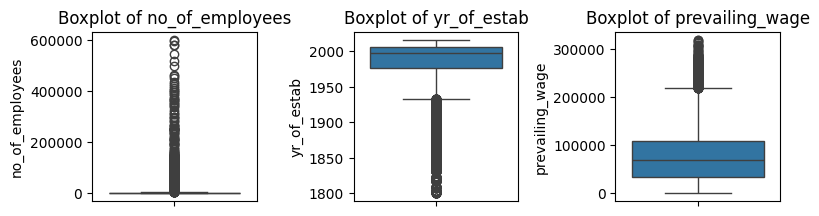

In [30]:
box_num(df, num_col)

In [31]:
df_processed = df.copy()

def calculate_annual_wage(row):
    wage = row['prevailing_wage']
    unit = row['unit_of_wage']
    if unit == 'Year':
        return wage
    elif unit == 'Month':
        return wage * 12
    elif unit == 'Week':
        return wage * 52
    elif unit == 'Hour':
        # Assuming a 40-hour work week
        return wage * 40 * 52
    else:
        return wage


In [32]:
print("Creating 'annual_wage' feature by standardizing 'prevailing_wage'...")
df_processed['annual_wage'] = df_processed.apply(calculate_annual_wage, axis=1)
df_processed.head()

Creating 'annual_wage' feature by standardizing 'prevailing_wage'...


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,annual_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,1231782.032
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.650
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,122996.860
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,83434.030
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,149907.390


In [33]:
def drop_col(data):
    data = data.drop(['prevailing_wage', 'unit_of_wage', 'case_id'], axis=1)
    return data

In [34]:
df_processed = drop_col(df_processed)

In [35]:
def comp_age(df_processed):
    current_year = 2016
    df_processed['company_age'] = current_year - df_processed['yr_of_estab']
    df_processed = df_processed.drop('yr_of_estab', axis=1)
    print("Created 'company_age' feature and dropped 'yr_of_estab'.")
    print("\n--- New 'annual_wage' feature ---")
    print(df_processed.describe())
    return df_processed

In [36]:
df_processed = comp_age(df_processed)

Created 'company_age' feature and dropped 'yr_of_estab'.

--- New 'annual_wage' feature ---
       no_of_employees   annual_wage   company_age
count     25480.000000  2.548000e+04  25480.000000
mean       5667.089207  1.973912e+05     36.590071
std       22877.917453  5.785917e+05     42.366929
min          11.000000  1.000000e+02      0.000000
25%        1022.000000  4.710796e+04     11.000000
50%        2109.000000  8.283946e+04     19.000000
75%        3504.000000  1.248250e+05     40.000000
max      602069.000000  1.456915e+07    216.000000


In [37]:
df_processed.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,case_status,annual_wage,company_age
0,Asia,High School,N,N,14513,West,Y,Denied,1231782.032,9
1,Asia,Master's,Y,N,2412,Northeast,Y,Certified,83425.650,14
2,Asia,Bachelor's,N,Y,44444,West,Y,Denied,122996.860,8
3,Asia,Bachelor's,N,N,98,West,Y,Denied,83434.030,119
4,Africa,Master's,Y,N,1082,South,Y,Certified,149907.390,11


In [38]:
def plot_df(df_processed):
    plt.figure(figsize=(8, 6))
    sns.boxplot(hue='case_status', y='annual_wage', data=df_processed, palette='coolwarm', legend=False)
    plt.title('Standardized Annual Wage vs. Case Status')
    plt.ylabel('Annual Wage (Standardized)')
    plt.xlabel('Case Status')
    plt.show()

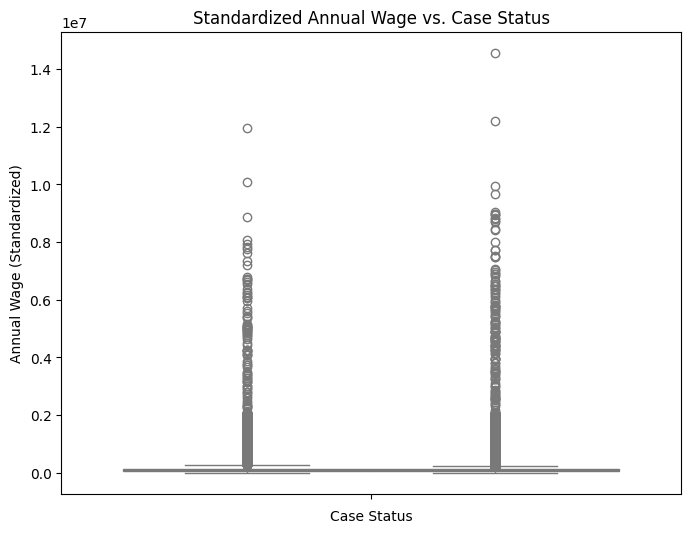

In [39]:
plot_df(df_processed)

In [40]:
numer_cols = df_processed.select_dtypes(["float64", "int64"]).columns
categ_cols = df_processed.select_dtypes("object").columns

In [41]:
print(numer_cols)
print(categ_cols)

Index(['no_of_employees', 'annual_wage', 'company_age'], dtype='object')
Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'full_time_position',
       'case_status'],
      dtype='object')


In [42]:
def box_num(df_processed, numer_col):
    numer_col = df_processed.select_dtypes(include=np.number).columns.tolist()


    # Plot the boxplots for all numeric columns (except Risk)
    plt.figure(figsize=(8, 6))

    for i, variable in enumerate(numer_col):
        plt.subplot(3, 3, i + 1)
        sns.boxplot(data=df_processed, y=variable)
        plt.title(f'Boxplot of {variable}')
        plt.tight_layout()

    plt.show()

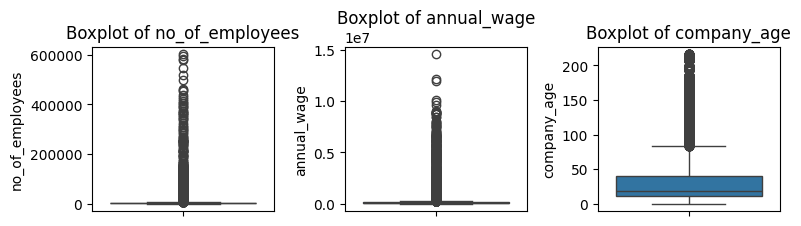

In [43]:
box_num(df_processed, numer_cols)

In [44]:
# def remove_outliers(data, columns):
#     """
#     Removes outliers from the specified columns of the dataframe using the IQR method.

#     Parameters:
#     data (pd.DataFrame): The dataframe to remove outliers from.
#     columns (list): List of columns to check for outliers.

#     Returns:
#     pd.DataFrame: Dataframe with outliers removed.
#     """
#     for col in columns:
#         # Calculate Q1 (25th percentile) and Q3 (75th percentile)
#         Q1 = data[col].quantile(0.25)
#         Q3 = data[col].quantile(0.75)

#         # Calculate the IQR (Interquartile Range)
#         IQR = Q3 - Q1

#         # Define bounds for outliers
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR

#         # Remove outliers
#         data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

#     return data

In [45]:
# cleaned_data = remove_outliers(df_processed, numer_cols)

# print(f"Original data shape: {df_processed.shape}")
# print(f"Cleaned data shape: {cleaned_data.shape}")
# data = cleaned_data

In [46]:
# data.head()

In [47]:
def box_num(df_processed, numer_cols):
    numer_col = df_processed.select_dtypes(include=np.number).columns.tolist()


    # Plot the boxplots for all numeric columns (except Risk)
    plt.figure(figsize=(8, 6))

    for i, variable in enumerate(numer_cols):
        plt.subplot(3, 3, i + 1)
        sns.boxplot(data=df_processed, y=variable)
        plt.title(f'Boxplot of {variable}')
        plt.tight_layout()

    plt.show()

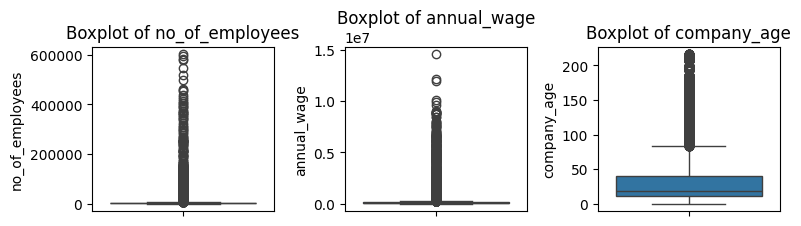

In [48]:
box_num(df_processed, numer_cols)

In [49]:
df_processed.columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'region_of_employment',
       'full_time_position', 'case_status', 'annual_wage', 'company_age'],
      dtype='object')

In [50]:
def log_transform_cols(df_processed, numer_cols):
    for c in numer_cols:
        if c in df_processed.columns:
            df_processed[c + '_log1p'] = np.log1p(df_processed[c].fillna(0))
    return df_processed

In [51]:
df_log = log_transform_cols(df_processed, numer_cols)
df_log.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,case_status,annual_wage,company_age,no_of_employees_log1p,annual_wage_log1p,company_age_log1p
0,Asia,High School,N,N,14513,West,Y,Denied,1231782.032,9,9.582869,14.023973,2.302585
1,Asia,Master's,Y,N,2412,Northeast,Y,Certified,83425.650,14,7.788626,11.331723,2.708050
2,Asia,Bachelor's,N,Y,44444,West,Y,Denied,122996.860,8,10.702008,11.719922,2.197225
3,Asia,Bachelor's,N,N,98,West,Y,Denied,83434.030,119,4.595120,11.331824,4.787492
4,Africa,Master's,Y,N,1082,South,Y,Certified,149907.390,11,6.987490,11.917780,2.484907


In [52]:
num_col_log = df_log.select_dtypes(["float64", "int64"]).columns
cat_col_log = df_log.select_dtypes("object").columns

In [ ]:
def plot_log(df_log, num_col_log):
    numer_cols = df_processed.select_dtypes(include=np.number).columns.tolist()


    plt.figure(figsize=(8, 6))

    for i, variable in enumerate(num_col_log):
        plt.subplot(3, 3, i + 1)
        sns.boxplot(data=df_log, y=variable)
        plt.title(f'Boxplot of {variable}')
        plt.tight_layout()
        plt.show()

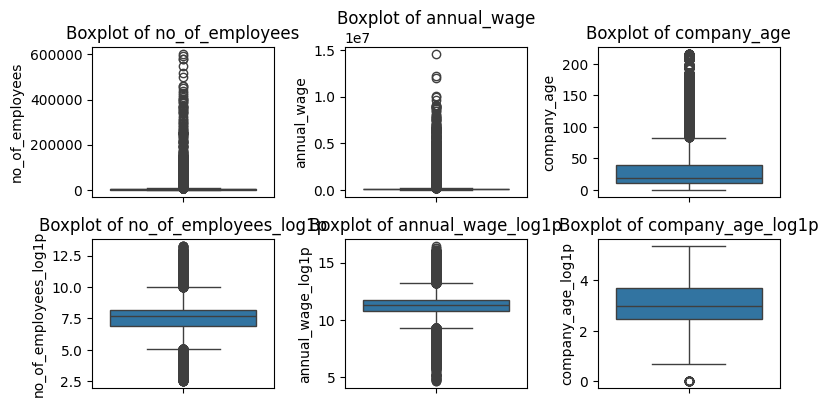

In [54]:
plot_log(df_log, num_col_log)

In [55]:
def histogram_boxplot(df_log, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df_log, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=df_log, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=df_log, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df_log[feature].mean(), color="green", linestyle="--"
    )  # Adding mean to the histogram
    ax_hist2.axvline(
        df_log[feature].median(), color="black", linestyle="-"
    )  # Adding median to the histogram

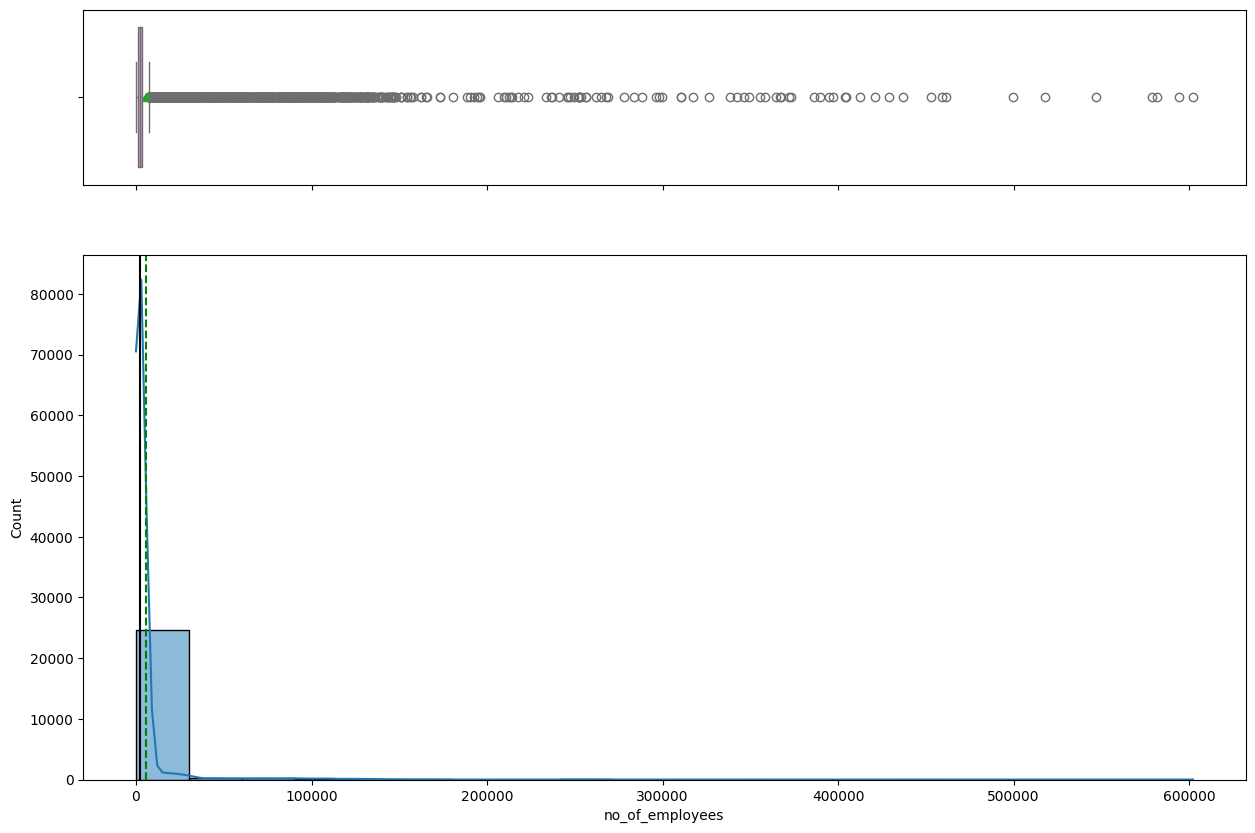

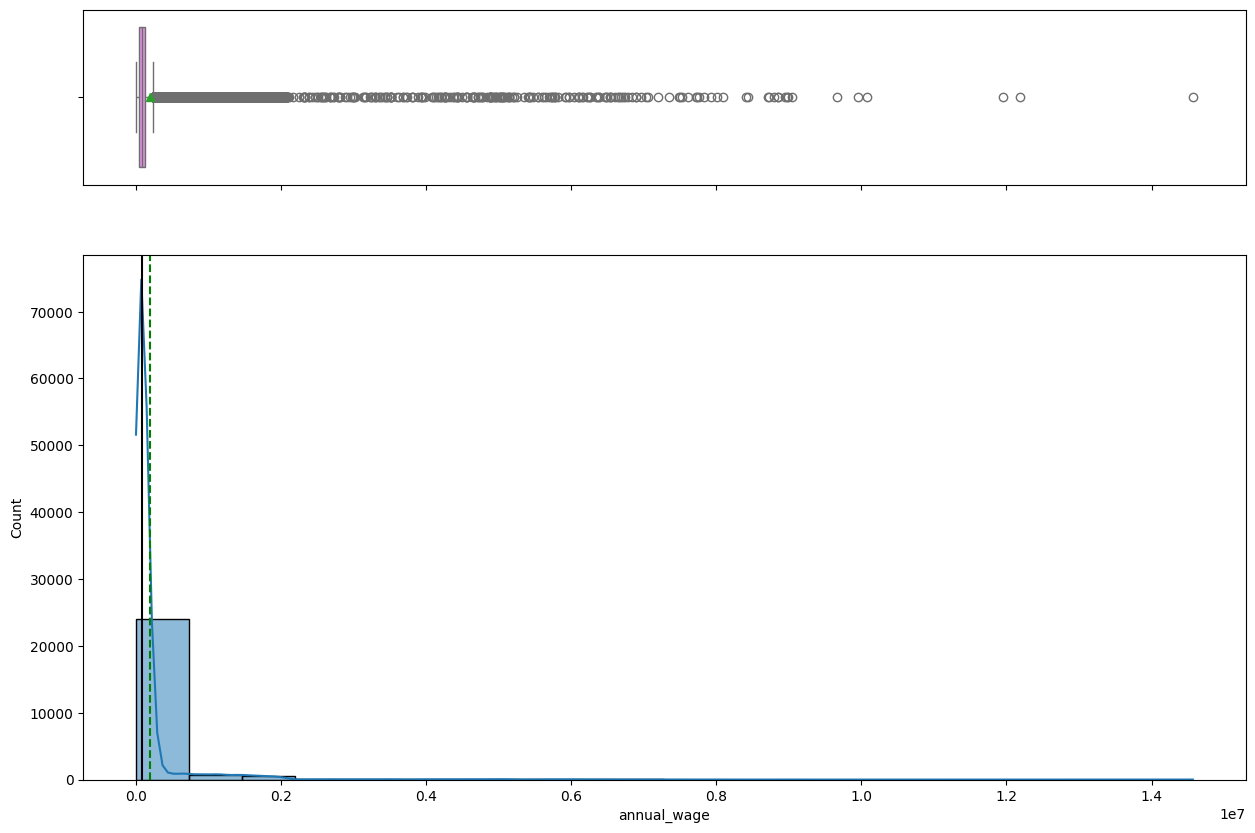

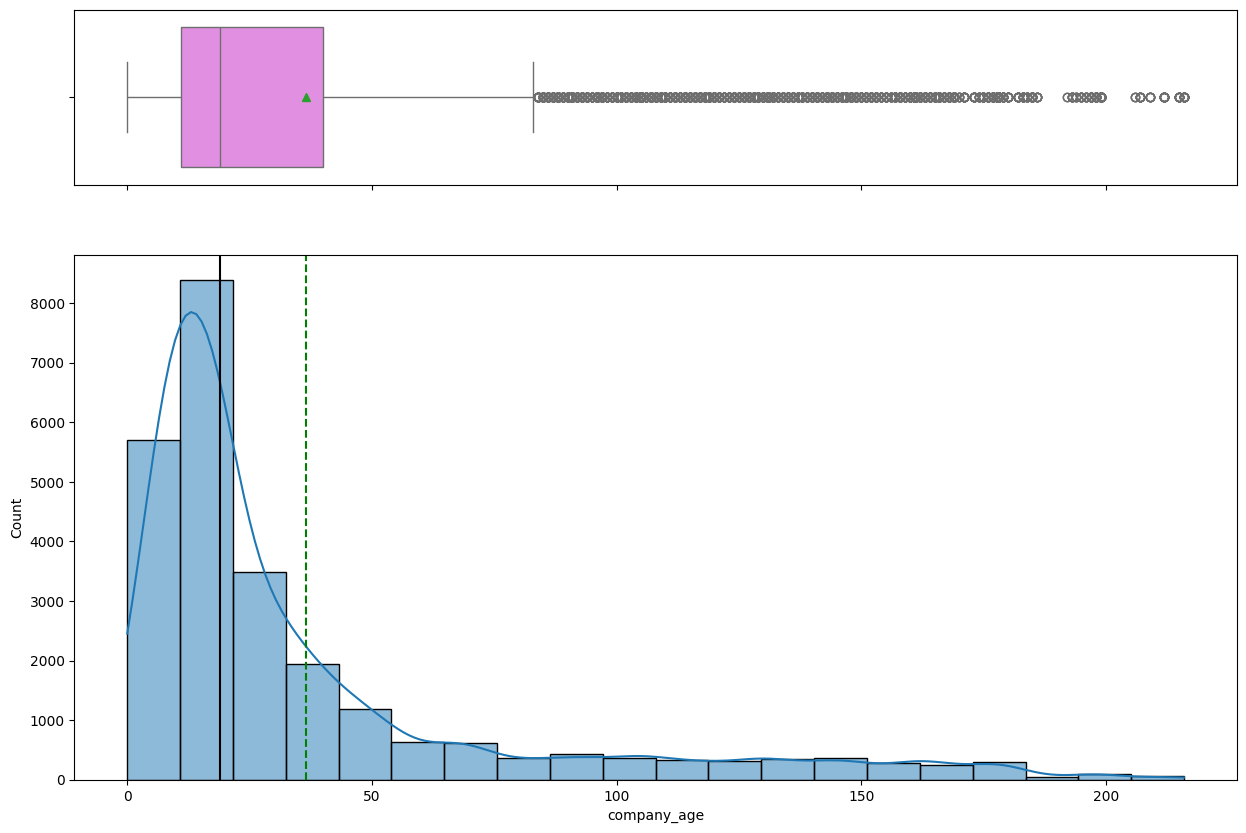

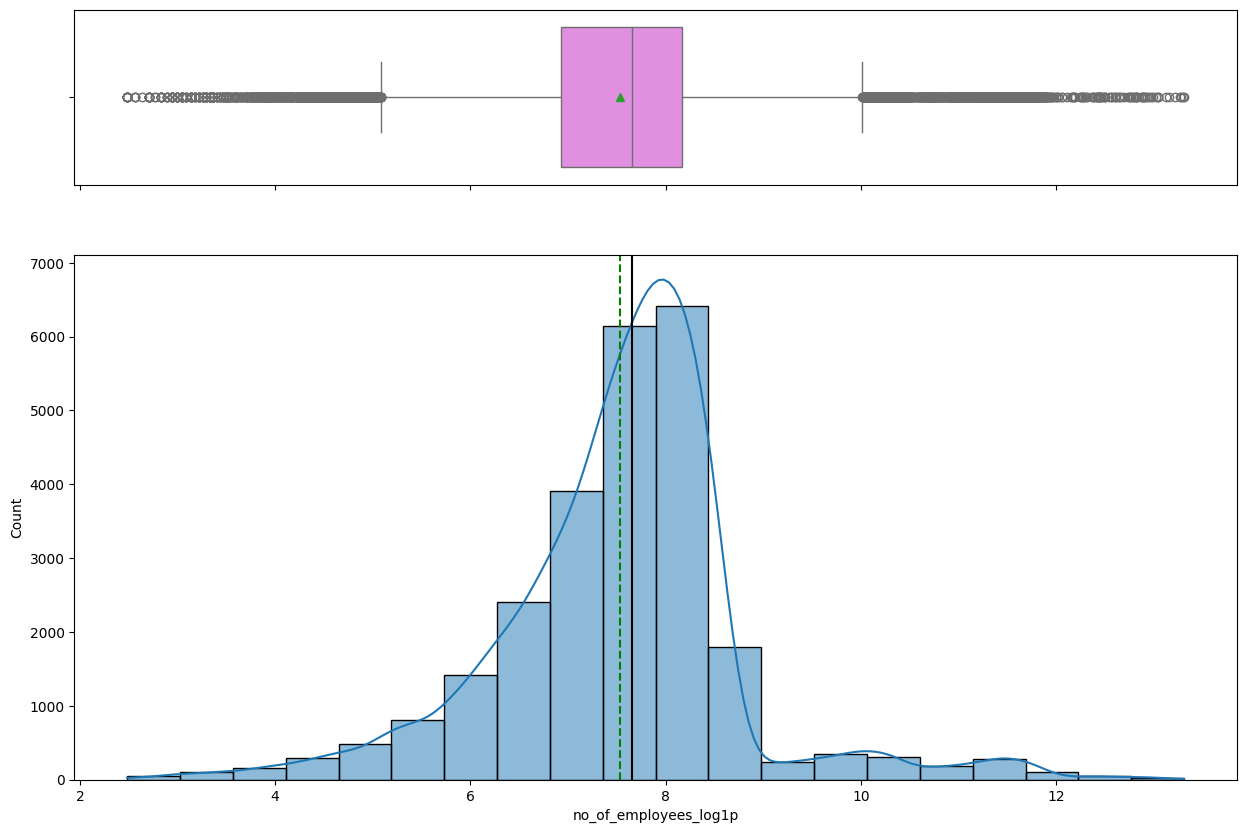

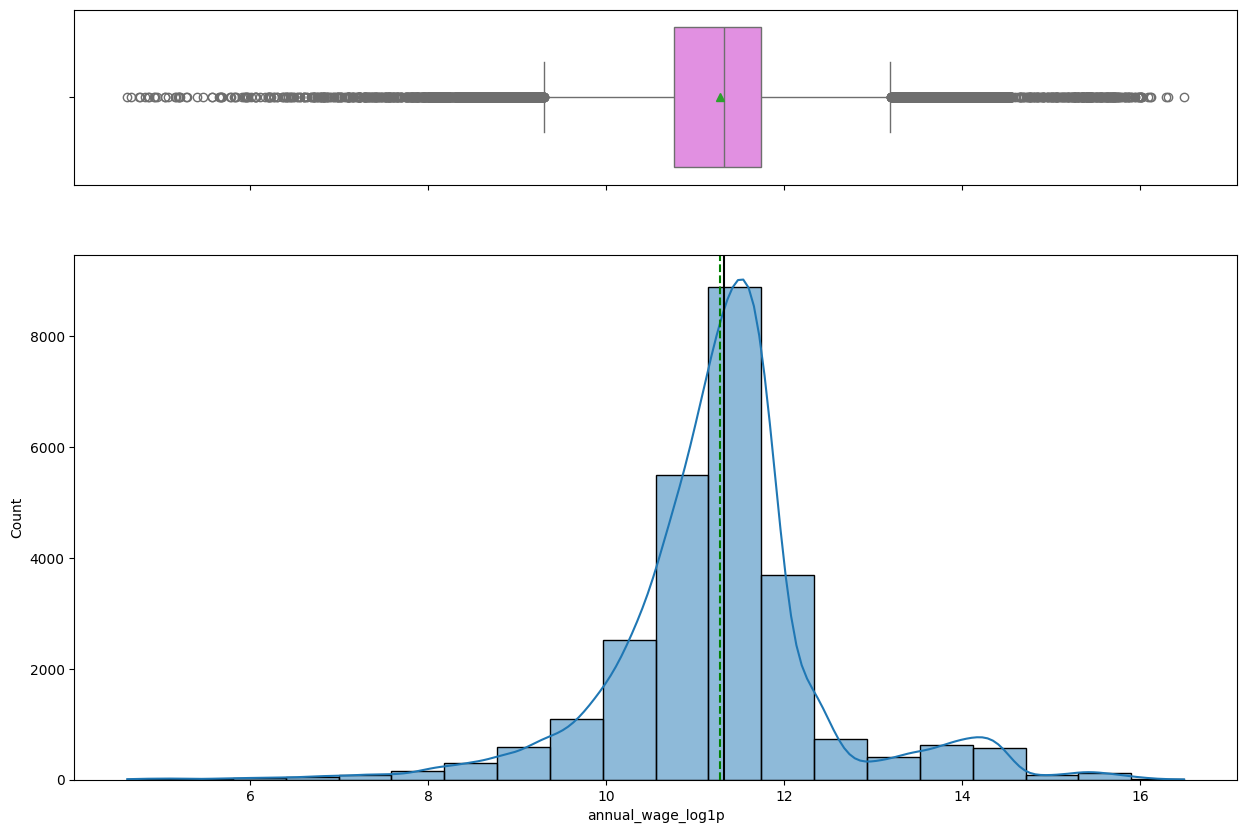

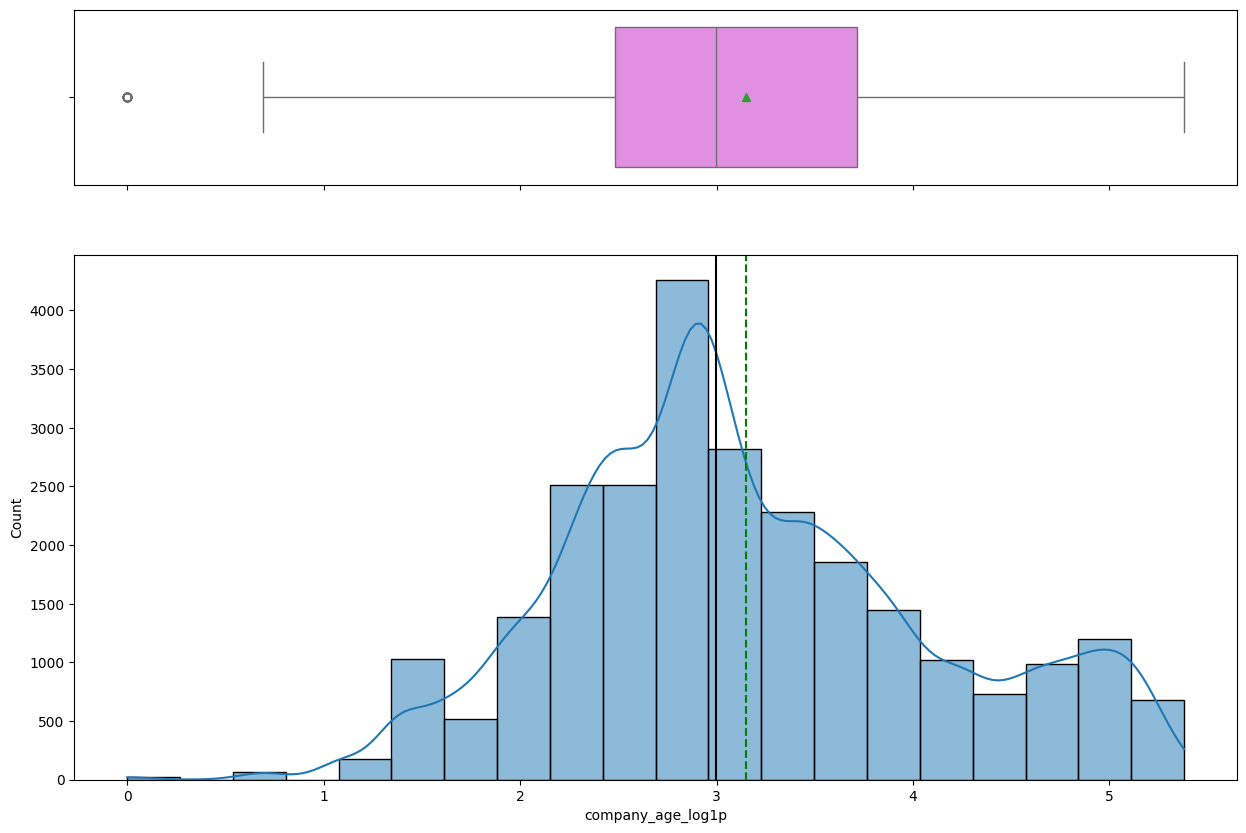

In [56]:
for num in num_col_log:
    histogram_boxplot(df_log, num, kde=True, bins=20)

In [59]:
def correlation(df_log, num_col_log):
    plt.figure(figsize=(10, 5))
    sns.heatmap(
    df_log[num_col_log].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Accent"
    )
    plt.show()

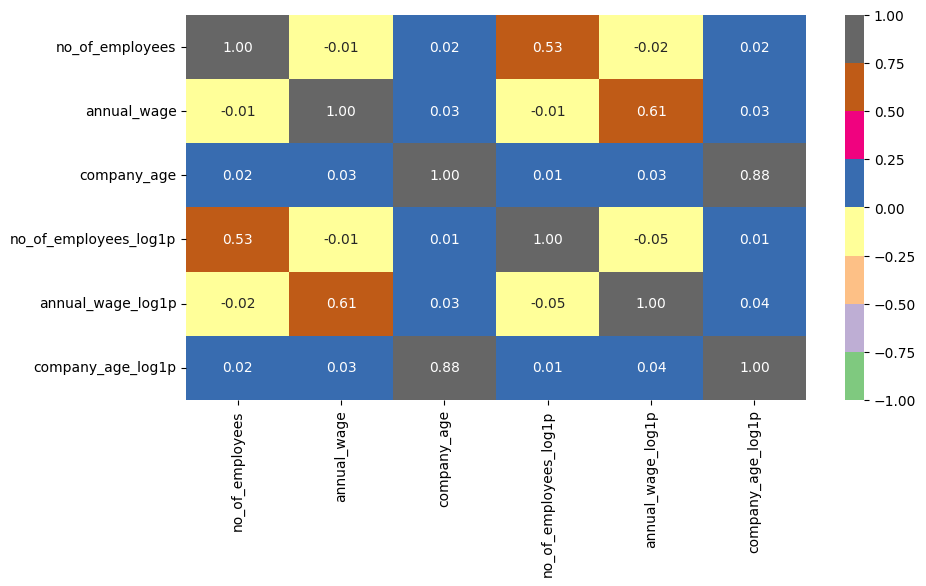

In [60]:
correlation(df_log, num_col_log)
# print(df_log.columns)
# print(numer_cols)

In [62]:
df_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   region_of_employment   25480 non-null  object 
 6   full_time_position     25480 non-null  object 
 7   case_status            25480 non-null  object 
 8   annual_wage            25480 non-null  float64
 9   company_age            25480 non-null  int64  
 10  no_of_employees_log1p  25480 non-null  float64
 11  annual_wage_log1p      25480 non-null  float64
 12  company_age_log1p      25480 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.5+ MB


In [63]:
print(df_log['case_status'].value_counts())

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64
